# **Análisis Exploratorio de los Datos**

Nuestra base de datos de interés recibe el nombre de *Lending Club Loan Data (2007–2020)*. Esta fue descargada del repositorio global [Kaggle](https://www.kaggle.com/datasets/wordsforthewise/lending-club). Cuenta con más de **1,3 millones de registros** y con variables socioeconómicas, financieras, de crédito, empleo y propósito del préstamo, etc.

## **Librerías**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
warnings.filterwarnings('ignore')
from statsmodels.stats.outliers_influence import variance_inflation_factor

## **Sobre la base de datos**

In [2]:
data = pd.read_csv('../data/aceptados.csv')
data

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.0,35000.0,35000.0,60 months,14.85,829.90,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260696,88985880,NaN,40000.0,40000.0,40000.0,60 months,10.49,859.56,B,B3,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260697,88224441,NaN,24000.0,24000.0,24000.0,60 months,14.49,564.56,C,C4,...,NaN,NaN,Cash,Y,Mar-2019,ACTIVE,Mar-2019,10000.0,44.82,1.0
2260698,88215728,NaN,14000.0,14000.0,14000.0,60 months,14.49,329.33,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2260699,Total amount funded in policy code 1: 1465324575,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### **Variable objetivo: default**

Antes de iniciar el análisis de nuestros datos, vamos a crear la columna correspondiente a la variable objetivo. En este caso, vamos a basarnos en la variable `loan_status` y consideraremos únicamente las categorías: **Fully Paid** (0) y **Charged Off** (1).

In [3]:
data = data[data['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
data["default"] = data["loan_status"].apply(lambda x: 1 if x == "Charged Off" else 0)

In [4]:
data['default'].value_counts()

default
0    1076751
1     268559
Name: count, dtype: int64

In [5]:
default_counts = data['default'].value_counts(normalize = True)
default_counts

default
0    0.800374
1    0.199626
Name: proportion, dtype: float64

Al analizar la columna `default`, que indica si un préstamo se paga completamente o no, encontramos una distribución desbalanceada. En total, se registran **1076751 (80.04%)** observaciones con un valor correspondiente a 0, lo que significa que el crédito se pagará en su totalidad. Por otro lado, solo **268559 (19.96%)** observaciones tienen un valor de 1, indicando que el préstamo quedará en default.

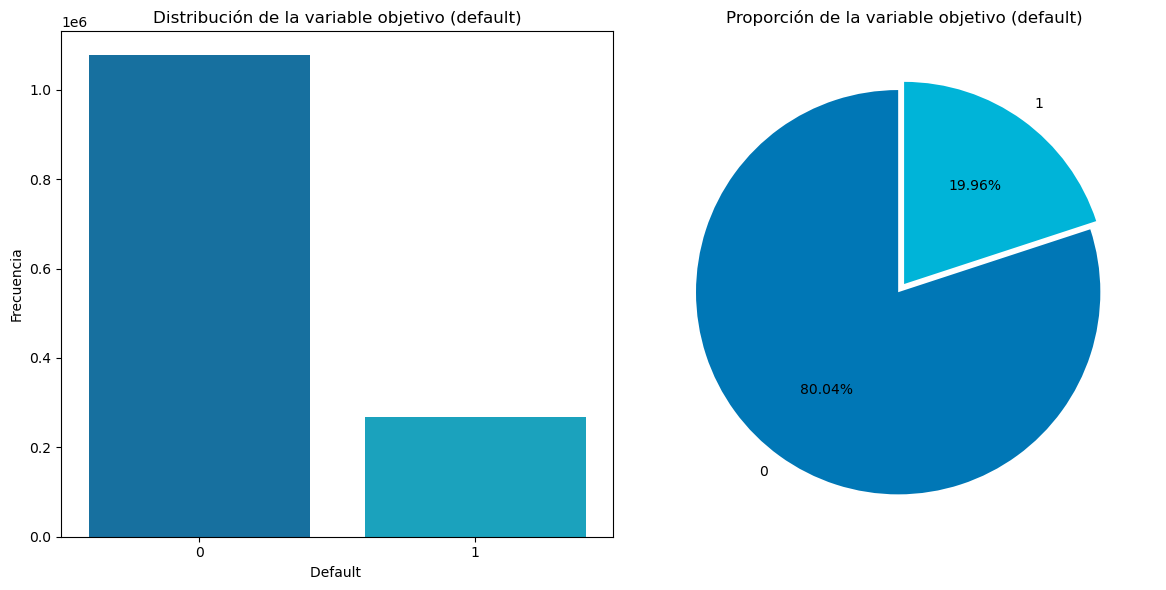

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

sns.countplot(x = data['default'], hue = data['default'], palette = ['#0077b6', '#00b4d8'], legend = False, ax=axes[0])
axes[0].set_title('Distribución de la variable objetivo (default)')
axes[0].set_xlabel('Default ')
axes[0].set_ylabel('Frecuencia')

default_counts.plot(kind = 'pie', autopct = '%1.2f%%', colors = ['#0077b6', '#00b4d8'], startangle = 90, explode = (0.05, 0), ax = axes[1])
axes[1].set_title('Proporción de la variable objetivo (default)')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

En estos dos gráficos, podemos observar más claramente el desbalanceo presente en nuestra variable objetivo. En este orden de ideas, se puede afirmar que, entre las observaciones, las que predominan son aquellas que corresponden a préstamos para pagar completamente.

Luego de analizar la variable objetivo, procedemos a borrar la variable `loan_status` del conjunto de datos pues contiene la misma exacta información que `default`.

In [7]:
data =data.drop(columns=['loan_status'])

### **Base de datos**

En cuanto a la base de datos, la de interés para este ejercicio fue la resultante de filtrar la variable `loan_status` y crear la variable objetivo `default`.

Esta es la que se usará para todo el procedimiento restante.

In [8]:
data

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term,default
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
4,68476807,NaN,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
5,68426831,NaN,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,NaN,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260690,88948836,NaN,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0
2260691,89996426,NaN,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,1
2260692,90006534,NaN,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,...,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN,0


In [9]:
data.shape

(1345310, 151)

El conjunto de datos contiene información de **1345310** préstamos aceptados, con **151** variables en total, entre las cuales **150** son características que describen a cada uno de estos, y una última variable binaria que corresponde a la variable objetivo de este proyecto.

In [10]:
data.columns

Index(['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv',
       'term', 'int_rate', 'installment', 'grade', 'sub_grade',
       ...
       'hardship_last_payment_amount', 'disbursement_method',
       'debt_settlement_flag', 'debt_settlement_flag_date',
       'settlement_status', 'settlement_date', 'settlement_amount',
       'settlement_percentage', 'settlement_term', 'default'],
      dtype='object', length=151)

In [11]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1345310 entries, 0 to 2260697
Columns: 151 entries, id to default
dtypes: float64(113), int64(1), object(37)
memory usage: 1.5+ GB


Entre todas las variables, **37** de ellas son de tipo **object** y las restantes de tipo **numérico**.



In [12]:
data.describe()

,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,...,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term,default
count,0.0,1.345310e+06,1.345310e+06,1.345310e+06,1.345310e+06,1.345310e+06,1.345310e+06,1.344936e+06,1.345310e+06,1.345310e+06,...,5754.000000,5754.0,5754.000000,3759.000000,5754.000000,5754.000000,33276.000000,33276.000000,33276.000000,1.345310e+06
mean,NaN,1.441997e+04,1.441156e+04,1.438914e+04,1.323962e+01,4.380755e+02,7.624764e+04,1.828267e+01,3.177944e-01,6.961850e+02,...,147.434105,3.0,13.949426,410.696640,10995.141594,184.689314,5029.933417,47.691708,13.158132,1.996261e-01
std,NaN,8.717051e+03,8.713118e+03,8.715494e+03,4.768716e+00,2.615126e+02,6.992510e+04,1.116045e+01,8.779922e-01,3.185251e+01,...,128.468905,0.0,9.777414,357.512115,7474.257379,196.459790,3684.827275,7.306107,8.235592,3.997195e-01
min,NaN,5.000000e+02,5.000000e+02,0.000000e+00,5.310000e+00,4.930000e+00,0.000000e+00,-1.000000e+00,0.000000e+00,6.250000e+02,...,0.640000,3.0,0.000000,1.920000,55.730000,0.010000,44.210000,0.200000,0.000000,0.000000e+00
25%,NaN,8.000000e+03,8.000000e+03,7.875000e+03,9.750000e+00,2.484800e+02,4.578000e+04,1.179000e+01,0.000000e+00,6.700000e+02,...,53.267500,3.0,5.000000,147.450000,5037.307500,39.570000,2228.617500,45.000000,6.000000,0.000000e+00
50%,NaN,1.200000e+04,1.200000e+04,1.200000e+04,1.274000e+01,3.754300e+02,6.500000e+04,1.761000e+01,0.000000e+00,6.900000e+02,...,109.820000,3.0,15.000000,303.450000,9305.100000,120.970000,4174.680000,45.000000,14.000000,0.000000e+00
75%,NaN,2.000000e+04,2.000000e+04,2.000000e+04,1.599000e+01,5.807300e+02,9.000000e+04,2.406000e+01,0.000000e+00,7.100000e+02,...,203.350000,3.0,23.000000,564.825000,15302.360000,267.605000,6884.237500,50.000000,18.000000,0.000000e+00
max,NaN,4.000000e+04,4.000000e+04,4.000000e+04,3.099000e+01,1.719830e+03,1.099920e+07,9.990000e+02,3.900000e+01,8.450000e+02,...,943.940000,3.0,37.000000,2343.150000,39542.450000,1407.860000,33601.000000,521.350000,181.000000,1.000000e+00


In [13]:
data.describe(include=['object'])

,id,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,pymnt_plan,...,hardship_status,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_loan_status,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date
count,1345310,1345310,1345310,1345310,1259525,1266799,1345310,1345310,1345310,1345310,...,5754,5754,5754,5754,5754,1345310,1345310,33276,33276,33276
unique,1345310,2,7,35,378353,11,6,3,139,1,...,2,26,25,25,5,2,2,83,3,89
top,68407277,36 months,B,C1,Teacher,10+ years,MORTGAGE,Source Verified,Mar-2016,n,...,COMPLETED,Sep-2017,Dec-2017,Oct-2017,Late (16-30 days),Cash,N,Jan-2019,COMPLETE,Jan-2019
freq,1,1020743,392741,85494,21268,442199,665579,521273,48937,1345310,...,3759,1493,1108,1065,2596,1338410,1312034,2451,14497,1635


Ahora, identifiquemos cuáles variables tienen presencia de datos faltantes.

### **Datos faltantes**

Columnas con más del 50% de faltantes: 58


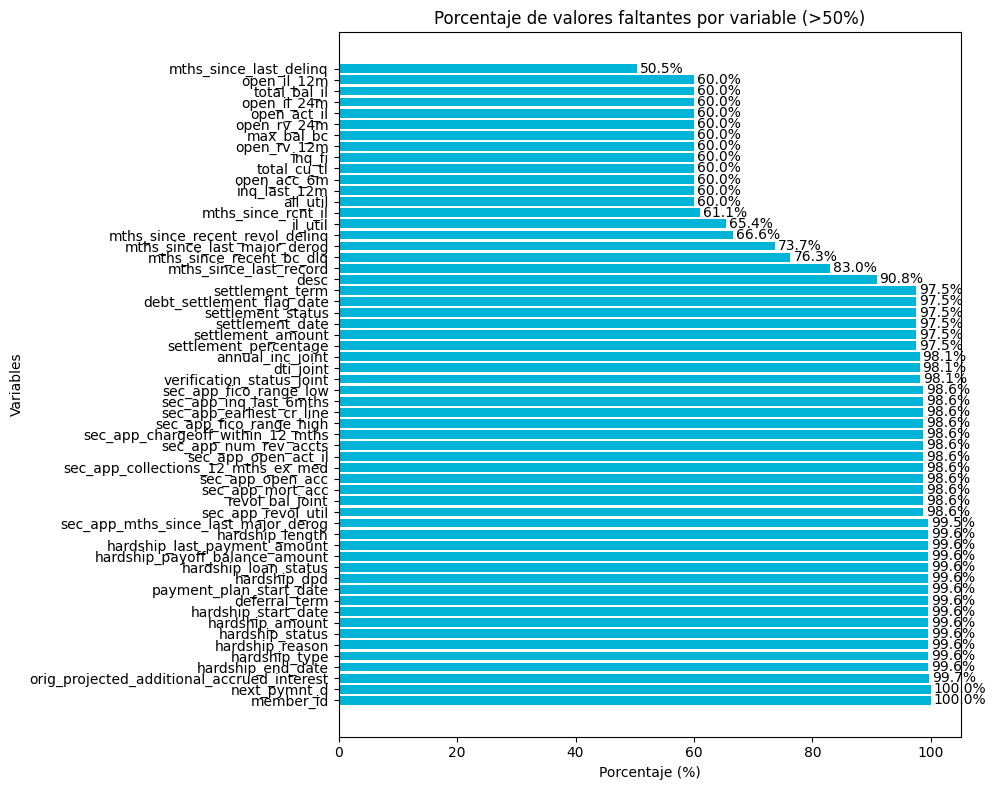

In [14]:
faltantesporc = data.isnull().mean() * 100

# Filtrar columnas con más del 50% de faltantes
faltantesporc = faltantesporc[faltantesporc > 50]

print(f"Columnas con más del 50% de faltantes: {len(faltantesporc)}")

datafaltante = pd.DataFrame({
    'Variable': faltantesporc.index,
    'Porcentaje_faltantes_total': faltantesporc.values
}).sort_values('Porcentaje_faltantes_total', ascending=False)

plt.figure(figsize=(10, 8))
bars = plt.barh(
    datafaltante['Variable'],
    datafaltante['Porcentaje_faltantes_total'],
    color='#00b4d8'
)

plt.xlabel('Porcentaje (%)')
plt.ylabel('Variables')
plt.title('Porcentaje de valores faltantes por variable (>50%)')
plt.xlim(0, datafaltante['Porcentaje_faltantes_total'].max() + 5)

for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')

plt.tight_layout()
plt.show()

En el gráfico se identifican **58** variables con más de un **50%** de datos faltantes. Dado que contienen poca información útil, se decidió eliminarlas. Con ello, se descarta aproximadamente un **38.41%** del total de variables de la base.

Cabe mencionar que la decisión de eliminar las columnas con más del 50% de valores faltantes se basa en el contexto de que los datos reflejan información de la vida real. Al intentar imputar columnas cuando la mayoría de los datos está ausente, existe un alto riesgo de introducir sesgos significativos, lo que podría afectar la calidad del conjunto de datos y generar errores en los modelos posteriores.

In [15]:
data = data.drop(columns=faltantesporc.index)
data

,id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,...,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,hardship_flag,disbursement_method,debt_settlement_flag,default
0,68407277,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,leadman,...,0.0,0.0,178050.0,7746.0,2400.0,13734.0,N,Cash,N,0
1,68355089,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,Engineer,...,0.0,0.0,314017.0,39475.0,79300.0,24667.0,N,Cash,N,0
2,68341763,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,truck driver,...,0.0,0.0,218418.0,18696.0,6200.0,14877.0,N,Cash,N,0
4,68476807,10400.0,10400.0,10400.0,60 months,22.45,289.91,F,F1,Contract Specialist,...,0.0,0.0,439570.0,95768.0,20300.0,88097.0,N,Cash,N,0
5,68426831,11950.0,11950.0,11950.0,36 months,13.44,405.18,C,C3,Veterinary Tecnician,...,0.0,0.0,16900.0,12798.0,9400.0,4000.0,N,Cash,N,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,89905081,18000.0,18000.0,18000.0,60 months,9.49,377.95,B,B2,NaN,...,0.0,0.0,275356.0,54349.0,13100.0,77756.0,N,Cash,N,0
2260690,88948836,29400.0,29400.0,29400.0,60 months,13.99,683.94,C,C3,Chief Operating Officer,...,0.0,0.0,719056.0,148305.0,56500.0,95702.0,N,Cash,N,0
2260691,89996426,32000.0,32000.0,32000.0,60 months,14.49,752.74,C,C4,Sales Manager,...,0.0,0.0,524379.0,122872.0,15800.0,23879.0,N,Cash,N,1
2260692,90006534,16000.0,16000.0,16000.0,60 months,12.79,362.34,C,C1,Manager,...,3.0,0.0,87473.0,65797.0,10100.0,73473.0,N,Cash,N,0


Así, el conjunto de datos conserva el mismo número de filas, pero ahora cuenta con **93** variables en total.

### **Limpieza del conjunto de datos**

Antes de realizar la imputación correspondiente a cada variable, vamos a identificar casos puntuales de algunas que también pueden ser eliminadas.

En particular, nos referimos a variables que causan ruido dentro del conjunto de datos por las distintas razones que se mencionan en cada caso.

#### **id & url**

Las variables `id` y `url` son identificadores únicos, es decir, todos los valores de las columnas son diferentes entre sí y lo único que hacen es identificar al préstamo específico, por lo tanto, no representan información relevante o útil para la predicción.

In [16]:
data['id'].nunique(), data['url'].nunique()

(1345310, 1345310)

In [17]:
# Eliminación de variables que son identificadores únicos
data = data.drop(columns=['id','url'])

#### **emp_title**

In [18]:
data['emp_title'].nunique()

378353

In [19]:
data['emp_title']

0                          leadman
1                         Engineer
2                     truck driver
4              Contract Specialist
5             Veterinary Tecnician
                    ...           
2260688                        NaN
2260690    Chief Operating Officer
2260691              Sales Manager
2260692                    Manager
2260697            Program Manager
Name: emp_title, Length: 1345310, dtype: object

En cuanto a `emp_title`, podemos identificar que hace referencia al cargo de la persona en su respectivo trabajo, sin embargo, se observa que fue una pregunta abierta por lo que no cuenta con categorías establecidas y, por ende, contiene demasiados valores únicos.

In [20]:
# Eliminación de variable que tiene muchas categorías
data = data.drop(columns=['emp_title'])

#### **grade & sub_grade**

Sobre la variable `grade` se puede mencionar que se identificó una relación con la variable `sub_grade`. Esto se puede observar en la siguiente tabla.

In [21]:
# Eliminación de grade porque subgrade la representa
datagradesinna = data.dropna(subset=['grade'])

gruppgrade = datagradesinna.groupby('grade')

def top_subgrades(series):
    if series.empty:
        return ""
    
    count_sub = series.value_counts()
    return ", ".join(count_sub.index)

top_subgrades_per_grade = gruppgrade['sub_grade'].apply(top_subgrades)

dataresult = top_subgrades_per_grade.to_frame(name="Top Subgrades")
dataresult.index.name = 'Grade'
dataresult = dataresult.reset_index()

tabla = (
    dataresult.style.set_caption("Subgrades más frecuentes por Grade")
    .set_properties(
        **{
            'font-size': '10pt',
            'border': '1px solid black',
            'background-color': 'white',
            'color': 'black'
        }
    )
    .set_table_styles([
        {
            'selector': 'th',
            'props': [('background-color', '#00b4d8'),
                      ('font-weight', 'bold'),
                      ('color', 'black')]
        }
    ])
    .hide(axis='index')
    .set_properties(subset=['Top Subgrades'], **{'text-align': 'center'})
)

display(tabla)

Grade,Top Subgrades
A,"A5, A4, A1, A3, A2"
B,"B4, B5, B3, B2, B1"
C,"C1, C2, C3, C4, C5"
D,"D1, D2, D3, D4, D5"
E,"E1, E2, E3, E4, E5"
F,"F1, F2, F3, F4, F5"
G,"G1, G2, G3, G4, G5"


Aquí vemos que todas las letras de `sub_grade` corresponden a la de `grade` por lo que se podría decir que transmiten la misma información. Sin embargo, la primera mencionada resulta ser más específica e informativa. Por temas de practicidad a la hora de modelar, se considerá quedarse con `grade`.

In [22]:
data = data.drop(columns=['sub_grade'])

#### **title & purpose**

Sobre la variable `title` se puede mencionar que se identificó una relación con la variable `purpose`. Esto se puede observar en la siguiente tabla.

In [23]:
# Eliminación de title porque purpose la representa
datatitlesinna = data.dropna(subset=['title'])

grupopurpose = datatitlesinna.groupby('purpose')

def toptitles(series):
    if series.empty:
        return ""
    
    counttitle = series.value_counts().head(3)
    
    formatted_text = []
    for title, count in counttitle.items():
        formatted_text.append(f"{title}")
    
    return ", ".join(formatted_text)

top_titles_per_purpose = grupopurpose['title'].apply(toptitles)

dataresult = top_titles_per_purpose.to_frame()
dataresult.rename(columns={'title': 'Títulos más comunes'}, inplace=True)
dataresult.index.name = 'Propósito'
dataresult = dataresult.reset_index()

tabla1 = dataresult.style.set_caption("Title según purpose") \
                               .set_properties(**{'font-size': '10pt', 'border': '1px solid black', 'background-color': 'white','color' :'black'}, ) \
                               .set_table_styles([
                                   {'selector': 'th', 'props': [('background-color', '#00b4d8'), ('font-weight', 'bold'), ('color', 'black')]}
                               ]) \
                               .hide(axis='index') \
                               .set_properties(subset=['Títulos más comunes'], **{'text-align': 'center'})
display(tabla1)

Propósito,Títulos más comunes
car,"Car financing, Car Loan, Auto Loan"
credit_card,"Credit card refinancing, Credit Card Refinance, Credit Card Consolidation"
debt_consolidation,"Debt consolidation, Debt Consolidation, debt consolidation"
educational,"Student Loan, Education, Personal Loan"
home_improvement,"Home improvement, Home Improvement, home improvement"
house,"Home buying, House Loan, Home Improvement"
major_purchase,"Major purchase, Major Purchase Loan, Major Purchase"
medical,"Medical expenses, Medical, Medical Loan"
moving,"Moving and relocation, Moving Loan, Moving"
other,"Other, Personal Loan, Personal"


Aquí podemos observar claramente que los distintos títulos propuestos caen sobre una misma categoría que está relacionada con los valores de `purpose`. Con esto en mente, procedemos a eliminar `title`.

In [24]:
data = data.drop(columns=['title'])

#### **Variables con un solo valor único**

Una práctica que vamos a realizar, es identificar si existen variables que, hasta este punto, cuentan con un solo valor único. Es decir, columnas que no tienen variabilidad y, por lo tanto, no son de utilidad.

In [25]:
dataunicos = data.nunique()

filtered_counts = dataunicos[dataunicos == 1].sort_values(ascending=False)

unicocounts_df = filtered_counts.to_frame(name='Valores Únicos')

tabla2 = unicocounts_df.style.set_caption("Variables con un solo valor único") \
                               .set_properties(**{'font-size': '10pt', 'border': '1px solid black', 'background-color': 'white', 'color': 'black'}) \
                               .set_table_styles([
                                   {'selector': 'th', 'props': [('background-color', '#00b4d8'), ('font-weight', 'bold'), ('color', 'black')]}
                               ]) \
                               .set_properties(subset=['Valores Únicos'], **{'text-align': 'center'})
display(tabla2)

,Valores Únicos
pymnt_plan,1
out_prncp,1
out_prncp_inv,1
policy_code,1
hardship_flag,1


In [26]:
dataunico1 = data[['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy_code', 'hardship_flag']]
dataunico1.isnull().sum()

pymnt_plan       0
out_prncp        0
out_prncp_inv    0
policy_code      0
hardship_flag    0
dtype: int64

En efecto, hay 5 columnas que presentan esta particularidad. Asimismo, se puede observar que no tienen datos faltantes. Procedemos entonces a eliminar las variables: `pymnt_plan`, `out_prncp`, `out_prncp_inv`, `policy_code` y `hardship_flag`.

In [27]:
data = data.drop(columns=['pymnt_plan', 'out_prncp', 'out_prncp_inv', 'policy_code', 'hardship_flag'])

#### **zip_code**

Finalmente, borraremos la variable `zip_code` debido a su gran cantidad de valores únicos, aparte de que, contamos ya con el estado en el que se encuentra la persona. Por ende, ya tenemos información relevante relacionada con la ubicación.

In [28]:
data['zip_code'].nunique()

943

In [29]:
data = data.drop(columns=['zip_code'])

#### **Variables post-predicción**

Un aspecto importante a considerar es la posible fuga de información en el conjunto de datos. 

Para este proyecto se realizaron distintas investigaciones con el fin de comprender a qué corresponde cada variable. En los trabajos analizados se compartía el diccionario correspondiente a este dataset (no disponible oficialmente para Colombia) y se identificó la existencia de variables asociadas a la etapa post de nuestra predicción objetivo.

A continuación, presentamos el diccionario de variables tomado del trabajo [*Lending Club EDA* (Amirtharajanpks, 2019)](https://www.kaggle.com/code/amirtharajanpks/lending-club-eda), en el cual resaltaremos aquellas que revelan datos que no se deberían saber durante la etapa de predicción.

| LoanStatNew                   | Descripción                                                                                                           |
|--------------------------------|-----------------------------------------------------------------------------------------------------------------------|
| acc_now_delinq                 | Número de cuentas en las que el prestatario actualmente está en mora.                                                |
| acc_open_past_24mths           | Número de cuentas abiertas en los últimos 24 meses.                                                                 |
| addr_state                     | Estado proporcionado por el prestatario en la solicitud de préstamo.                                               |
| all_util                       | Balance en relación con el límite de crédito en todas las cuentas.                                                  |
| annual_inc                     | Ingreso anual auto-reportado proporcionado por el prestatario durante el registro.                                  |
| annual_inc_joint               | Ingreso anual combinado auto-reportado por los co-prestatarios durante el registro.                                 |
| application_type               | Indica si el préstamo es una solicitud individual o conjunta con dos co-prestatarios.                               |
| avg_cur_bal                    | Saldo promedio actual de todas las cuentas.                                                                         |
| bc_open_to_buy                 | Total disponible para gastar en tarjetas de crédito revolventes.                                                   |
| bc_util                        | Proporción del saldo actual respecto al límite de crédito en todas las cuentas de tarjeta bancaria.                 |
| chargeoff_within_12_mths       | Número de deudas incobrables en los últimos 12 meses.                                                              |
| collection_recovery_fee         | Tarifas de recuperación tras incobrables.                                                                          |
| collections_12_mths_ex_med     | Número de cobros en los últimos 12 meses excluyendo cobros médicos.                                                |
| delinq_2yrs                    | Número de incidencias de morosidad de más de 30 días en los últimos 2 años.                                        |
| delinq_amnt                    | Monto pendiente de las cuentas en las que el prestatario está en mora.                                             |
| desc                           | Descripción del préstamo proporcionada por el prestatario.                                                         |
| dti                            | Ratio calculado usando los pagos mensuales totales del prestatario sobre todas las obligaciones de deuda, excluyendo hipoteca y el préstamo solicitado, dividido por su ingreso mensual auto-reportado. |
| dti_joint                      | Ratio calculado usando los pagos mensuales totales de los co-prestatarios sobre todas las obligaciones de deuda, excluyendo hipotecas y el préstamo solicitado, dividido por el ingreso combinado mensual auto-reportado de los co-prestatarios. |
| earliest_cr_line               | Mes en que se abrió la primera línea de crédito reportada del prestatario.                                         |
| emp_length                     | Antigüedad laboral en años (0 = menos de 1 año, 10 = 10 años o más).                                              |
| emp_title                      | Cargo o puesto del prestatario al solicitar el préstamo.                                                           |
| fico_range_high                | Límite superior del rango de FICO del prestatario al momento del préstamo.                                         |
| fico_range_low                 | Límite inferior del rango de FICO del prestatario al momento del préstamo.                                         |
| funded_amnt                     | Monto total comprometido para el préstamo en ese momento.                                                         |
| funded_amnt_inv                 | Monto total aportado por inversores para ese préstamo en ese momento.                                             |
| grade                           | Calificación de préstamo asignada por LC.                                                                         |
| home_ownership                  | Estado de propiedad de vivienda proporcionado por el prestatario (RENT, OWN, MORTGAGE, OTHER).                    |
| id                              | ID único asignado por LC para el préstamo.                                                                        |
| il_util                         | Proporción del saldo actual respecto al límite de crédito en cuentas a plazos.                                     |
| initial_list_status             | Estado inicial del listado del préstamo (W, F).                                                                  |
| inq_fi                          | Número de consultas de financiamiento personal.                                                                  |
| inq_last_12m                    | Número de consultas de crédito en los últimos 12 meses.                                                          |
| inq_last_6mths                  | Número de consultas de crédito en los últimos 6 meses (excluyendo autos e hipotecas).                             |
| installment                     | Pago mensual que el prestatario debe realizar si se aprueba el préstamo.                                          |
| int_rate                        | Tasa de interés del préstamo.                                                                                     |
| issue_d                         | Mes en que se financió el préstamo.                                                                              |
| last_credit_pull_d              | Último mes en que LC revisó el crédito para este préstamo.                                                       |
| last_fico_range_high            | Límite superior del rango de FICO más reciente del prestatario.                                                  |
| last_fico_range_low             | Límite inferior del rango de FICO más reciente del prestatario.                                                  |
| last_pymnt_amnt                 | Último monto total recibido de pago.                                                                             |
| last_pymnt_d                    | Último mes en que se recibió un pago.                                                                            |
| loan_amnt                        | Monto solicitado originalmente por el prestatario. Si se reduce, se refleja aquí.                               |
| loan_status                     | Estado actual del préstamo.                                                                                       |
| max_bal_bc                      | Saldo máximo actual en todas las cuentas revolventes.                                                            |
| member_id                        | ID único asignado al miembro prestatario.                                                                       |
| mo_sin_old_il_acct              | Meses desde que se abrió la cuenta a plazos más antigua.                                                        |
| mo_sin_old_rev_tl_op            | Meses desde que se abrió la cuenta revolvente más antigua.                                                      |
| mo_sin_rcnt_rev_tl_op           | Meses desde que se abrió la cuenta revolvente más reciente.                                                     |
| mo_sin_rcnt_tl                  | Meses desde que se abrió la cuenta más reciente.                                                               |


Al considerar estas definiciones, podemos entonces proceder a eliminar las siguientes variables que hablan del futuro de nuestro contexto.

In [30]:
data = data.drop(columns = ['collection_recovery_fee', 'last_pymnt_amnt', 'last_pymnt_d', 
     'recoveries', 'total_pymnt', 'total_pymnt_inv', 'total_rec_int', 'total_rec_late_fee', 'total_rec_prncp',
     'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low'])

Y ya con esto termina esta sección de limpieza de la base de datos. Ahora, contamos con un conjunto que tiene columnas con variabilidad, información útil para la predicción y que no van a ocasionar sesgo por explicar lo que se busca predecir.

### **Tratamiento de variables: mapeo e imputación de faltantes**

#### **Categóricas**

##### **Mapeo**

In [31]:
emp_length_mapping = {
    '10+ years': 10,
    '9 years': 9,
    '8 years': 8,
    '7 years': 7,
    '6 years': 6,
    '5 years': 5,
    '4 years': 4,
    '3 years': 3,
    '2 years': 2,
    '1 year': 1,
    '< 1 year': 0.5,
    'n/a': 0
}

data['emp_length'] = data['emp_length'].map(emp_length_mapping)

In [32]:
term_mapping = {
    '36 months': 36,
    '60 months': 60
}

data['term'] = data['term'].str.strip().str.lower()

data['term'] = data['term'].map(term_mapping)

In [33]:
# Convertir a datetime
data['issue_d'] = pd.to_datetime(data['issue_d'], format='%b-%Y')
data['earliest_cr_line'] = pd.to_datetime(data['earliest_cr_line'], format='%b-%Y')

# Calcular antigüedad en años (decimal)
data['credit_history_years'] = (data['issue_d'] - data['earliest_cr_line']).dt.days / 365

data = data.drop(columns=['issue_d', 'earliest_cr_line'])

En este código se toman las variables que corresponden a fecha y se pasan a ese formato. Una vez proporcionan la información tal como se espera, se considera crear una nueva variable denominada `credit_history_years`, la cual corresponde a la cantidad de años que han pasado desde el primer crédito obtenido por la persona.

In [34]:
cols = list(data.columns)
if 'default' in cols:
    cols.remove('default')
cols.append('default')
data = data[cols]

##### **Imputación**

In [35]:
datacol = data.select_dtypes(include='object')
(datacol.isnull().sum() / len(data)) * 100

grade                   0.0
home_ownership          0.0
verification_status     0.0
purpose                 0.0
addr_state              0.0
initial_list_status     0.0
application_type        0.0
disbursement_method     0.0
debt_settlement_flag    0.0
dtype: float64

Luego de haber hecho los respectivos mapeos y transformaciones pertinentes, observamos que las variables no cuentan con datos faltantes. Es decir, no requieren imputación.

#### **Numéricas**

In [36]:
datanum = data.select_dtypes(include=np.number)
datanum

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,emp_length,annual_inc,dti,delinq_2yrs,...,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,credit_history_years,default
0,3600.0,3600.0,3600.0,36,13.99,123.03,10.0,55000.0,5.91,0.0,...,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,12.342466,0
1,24700.0,24700.0,24700.0,36,11.99,820.28,10.0,65000.0,16.06,1.0,...,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,16.010959,0
2,20000.0,20000.0,20000.0,60,10.78,432.66,10.0,63000.0,10.78,0.0,...,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,15.342466,0
4,10400.0,10400.0,10400.0,60,22.45,289.91,3.0,104433.0,25.37,1.0,...,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,17.512329,0
5,11950.0,11950.0,11950.0,36,13.44,405.18,4.0,34000.0,10.20,0.0,...,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,28.186301,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,60,9.49,377.95,5.0,130000.0,20.59,0.0,...,100.0,33.3,0.0,0.0,275356.0,54349.0,13100.0,77756.0,12.260274,0
2260690,29400.0,29400.0,29400.0,60,13.99,683.94,9.0,180792.0,22.03,0.0,...,100.0,42.9,0.0,0.0,719056.0,148305.0,56500.0,95702.0,14.597260,0
2260691,32000.0,32000.0,32000.0,60,14.49,752.74,3.0,157000.0,10.34,0.0,...,100.0,0.0,0.0,0.0,524379.0,122872.0,15800.0,23879.0,5.339726,1
2260692,16000.0,16000.0,16000.0,60,12.79,362.34,10.0,150000.0,12.25,0.0,...,92.0,50.0,3.0,0.0,87473.0,65797.0,10100.0,73473.0,19.180822,0


##### **Imputación**

In [37]:
missingnum = datanum.isnull().sum()
missingnum = missingnum[missingnum > 0]
missingnum.shape[0]

42

Text(0, 0.5, 'Cantidad de variables')

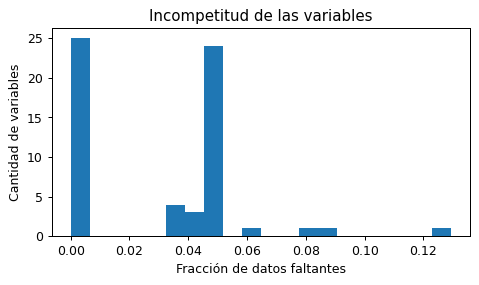

In [38]:
missing_fractions = datanum.isnull().sum() / len(datanum)
plt.figure(figsize=(6,3), dpi=90)
missing_fractions.plot.hist(bins=20)
plt.title('Incompetitud de las variables')
plt.xlabel('Fracción de datos faltantes')
plt.ylabel('Cantidad de variables')

El total de variables numéricas que tienen datos faltantes es de **42** y estos porcentajes varían entre **0% y 12% (aproximadamente)**.

In [39]:
datanum = datanum.fillna(datanum.median())

data[datanum.columns] = datanum

Para resolver el tema de los datos faltantes en el caso de las tipo numéricas, imputamos todas las variables con la mediana correspondiente a cada columna.

## **Análisis de las variables**

In [40]:
num_vars = data.select_dtypes(include=np.number).shape[1]
cat_vars = data.select_dtypes(exclude=np.number).shape[1]

print("\nCantidad de variables numéricas:", num_vars)
print("Cantidad de variables categóricas:", cat_vars)

pd.set_option('display.max_columns', None)
data


Cantidad de variables numéricas: 60
Cantidad de variables categóricas: 9


,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,credit_history_years,default
0,3600.0,3600.0,3600.0,36,13.99,123.03,C,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,675.0,679.0,1.0,7.0,0.0,2765.0,29.7,13.0,w,0.0,Individual,0.0,722.0,144904.0,9300.0,4.0,20701.0,1506.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,2.0,4.0,2.0,5.0,3.0,4.0,9.0,4.0,7.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,0.0,178050.0,7746.0,2400.0,13734.0,Cash,N,12.342466,0
1,24700.0,24700.0,24700.0,36,11.99,820.28,C,10.0,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,715.0,719.0,4.0,22.0,0.0,21470.0,19.2,38.0,w,0.0,Individual,0.0,0.0,204396.0,111800.0,4.0,9733.0,57830.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,5.0,13.0,17.0,6.0,20.0,27.0,5.0,22.0,0.0,0.0,0.0,2.0,97.4,7.7,0.0,0.0,314017.0,39475.0,79300.0,24667.0,Cash,N,16.010959,0
2,20000.0,20000.0,20000.0,60,10.78,432.66,B,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,695.0,699.0,0.0,6.0,0.0,7869.0,56.2,18.0,w,0.0,Joint App,0.0,0.0,189699.0,14000.0,6.0,31617.0,2737.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,10.0,0.0,2.0,3.0,2.0,4.0,6.0,4.0,7.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,50.0,0.0,0.0,218418.0,18696.0,6200.0,14877.0,Cash,N,15.342466,0
4,10400.0,10400.0,10400.0,60,22.45,289.91,F,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,695.0,699.0,3.0,12.0,0.0,21929.0,64.5,35.0,w,0.0,Individual,0.0,0.0,331730.0,34000.0,10.0,27644.0,4567.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,4.0,6.0,5.0,9.0,10.0,7.0,19.0,6.0,12.0,0.0,0.0,0.0,4.0,96.6,60.0,0.0,0.0,439570.0,95768.0,20300.0,88097.0,Cash,N,17.512329,0
5,11950.0,11950.0,11950.0,36,13.44,405.18,C,4.0,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,690.0,694.0,0.0,5.0,0.0,8822.0,68.4,6.0,w,0.0,Individual,0.0,0.0,12798.0,12900.0,0.0,2560.0,844.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,5.0,0.0,2.0,3.0,2.0,2.0,2.0,4.0,4.0,3.0,5.0,0.0,0.0,0.0,0.0,100.0,100.0,0.0,0.0,16900.0,12798.0,9400.0,4000.0,Cash,N,28.186301,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,18000.0,18000.0,60,9.49,377.95,B,5.0,OWN,130000.0,Not Verified,home_improvement,TX,20.59,0.0,735.0,739.0,1.0,17.0,0.0,23833.0,34.0,39.0,f,0.0,Individual,0.0,0.0,168758.0,70100.0,6.0,9927.0,4161.0,68.2,0.0,0.0,113.0,146.0,17.0,15.0,3.0,17.0,2.0,0.0,3.0,9.0,3.0,5.0,21.0,10.0,15.0,9.0,17.0,0.0,0.0,0.0,0.0,100.0,33.3,0.0,0.0,275356.0,54349.0,13100.0,77756.0,Cash,N,12.260274,0
2260690,29400.0,29400.0,29400.0,60,13.99,683.94,C,9.0,MORTGAGE,180792.0,Not Verified,debt_consolidation,CA,22.03,0.0,705.0,709.0,1.0,16.0,0.0,77480.0,85.2,32.0,f,0.0,Individual,0.0,0.0,663465.0,86500.0,4.0,44231.0,8427.0,69.4,0.0,0.0,145.0,174.0,31.0,8.0,3.0,70.0,3.0,0.0,4.0,5.0,7.0,9.0,17.0,8.0,10.0,5.0,16.0,0.0,0.0,0.0,2.0,100.0,42.9,0.0,0.0,719056.0,148305.0,56500.0,95702.0,Cash,N,14.5

Después de haber hecho un recorrido por la base de datos y haber encontrado variables que no eran de significancia o utilidad, quedamos con un conjunto de datos con **1345310** filas y **69** columnas.

Procederemos ahora a analizar las variables basado en su tipo y considerando la distribución de la variable objetivo en cada una.

### **Numéricas**

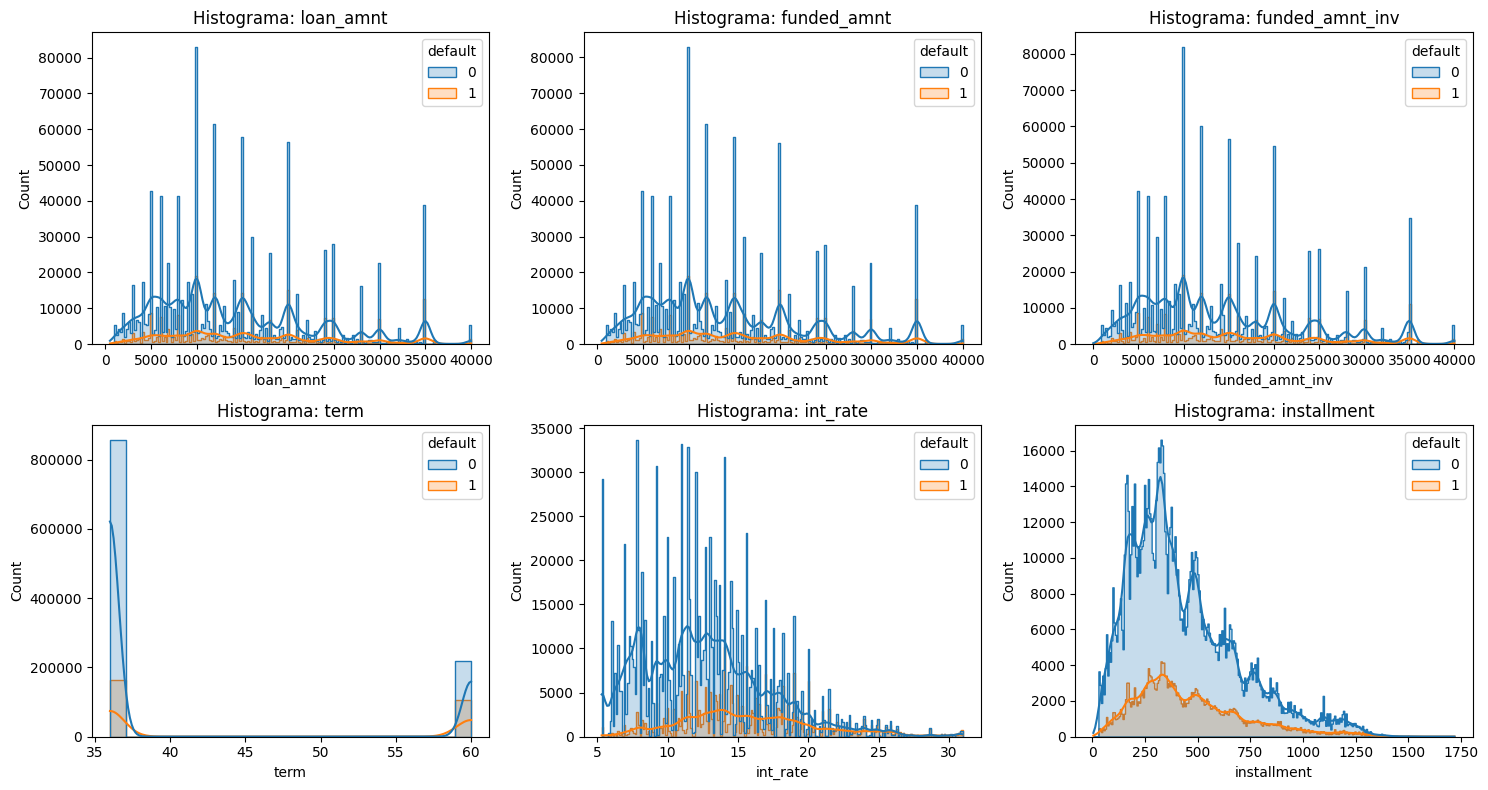

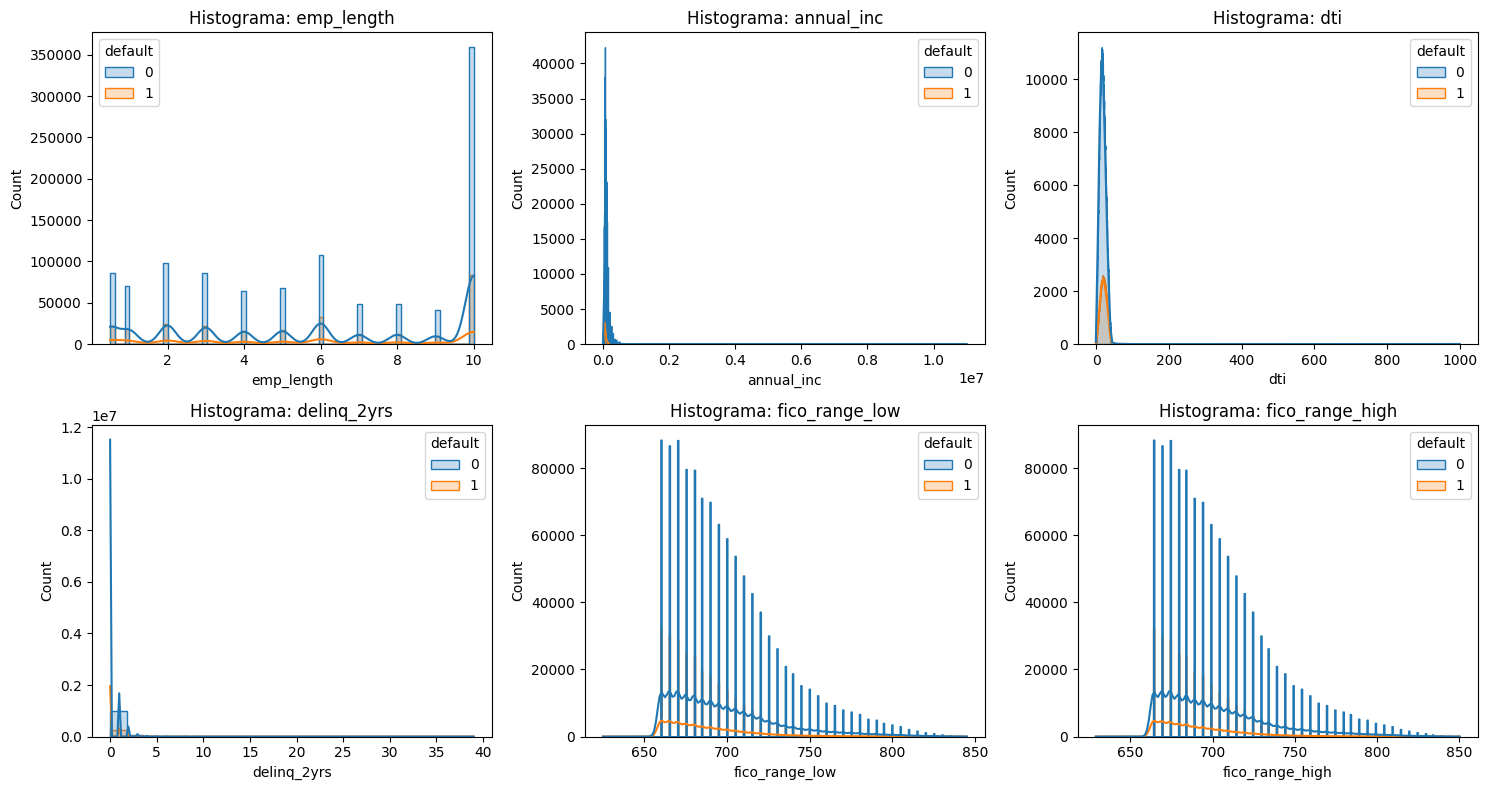

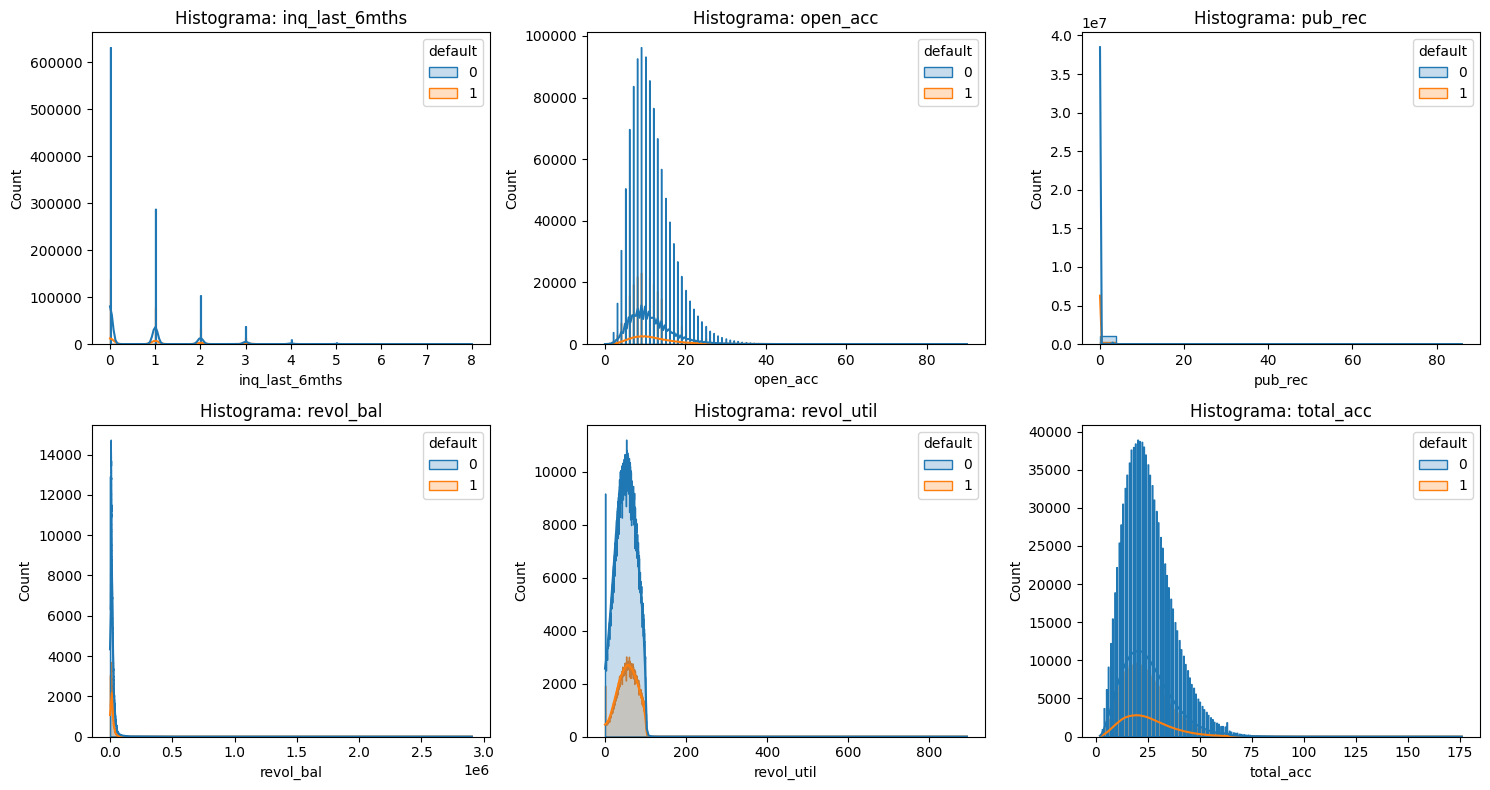

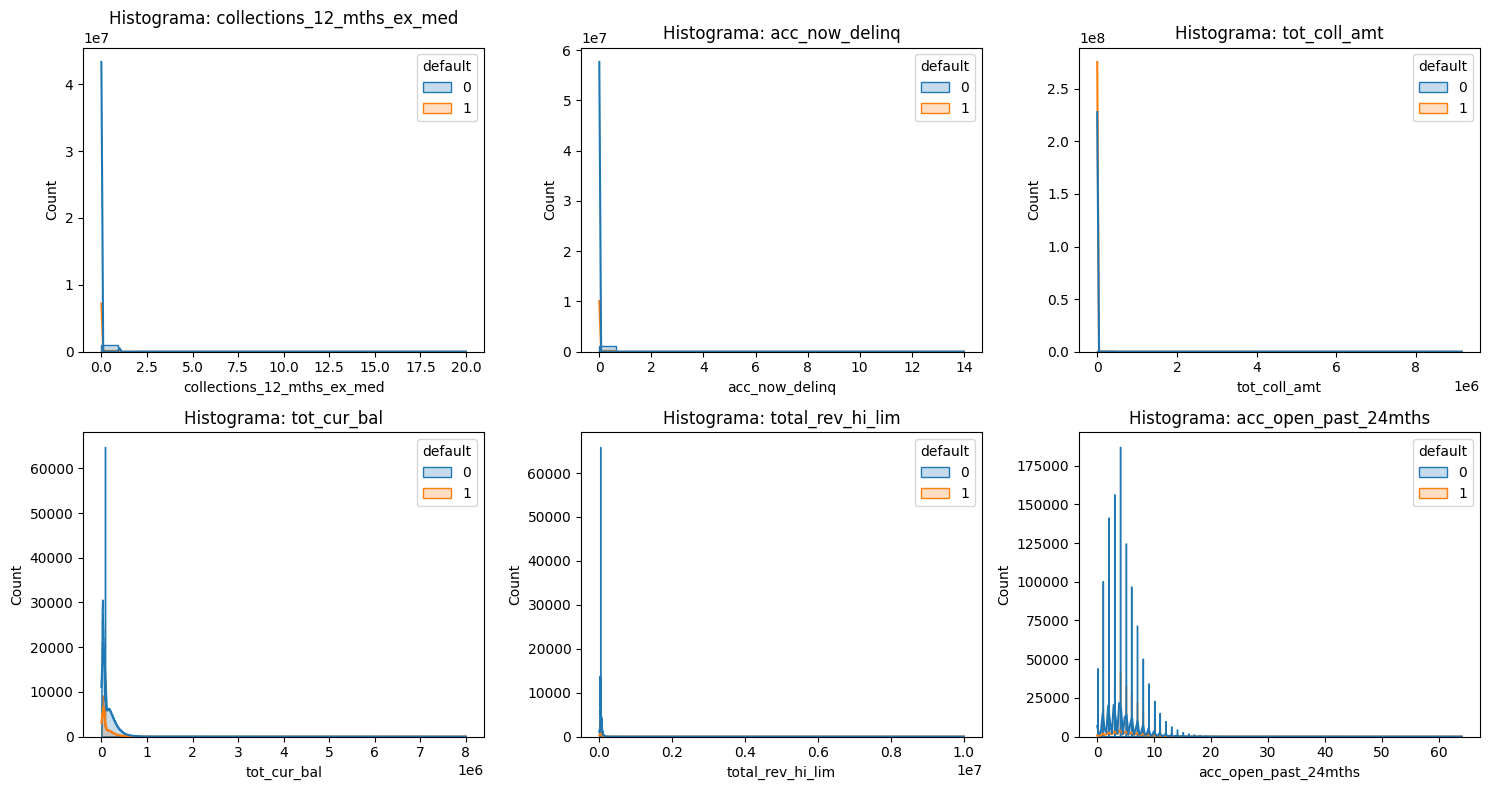

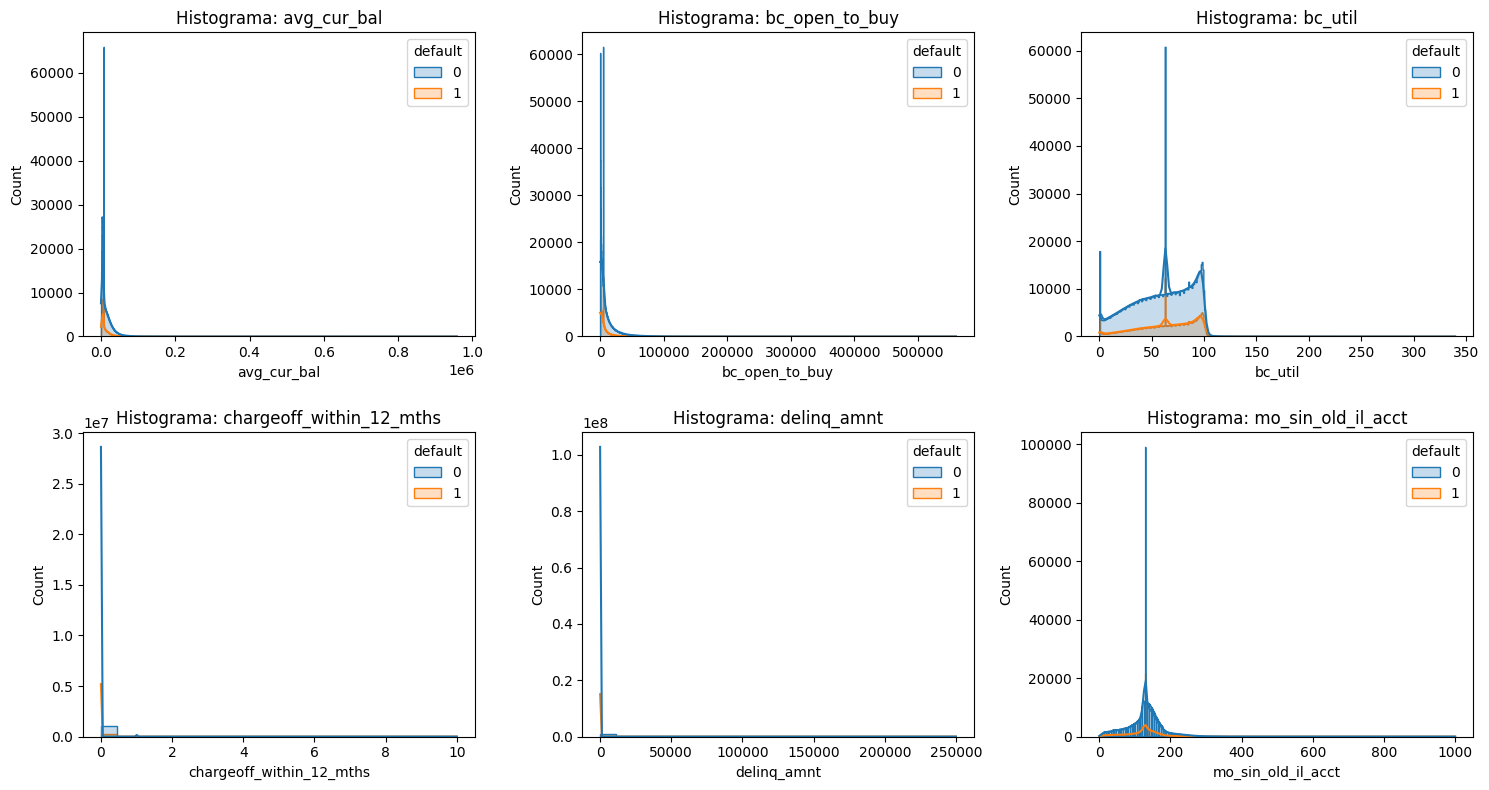

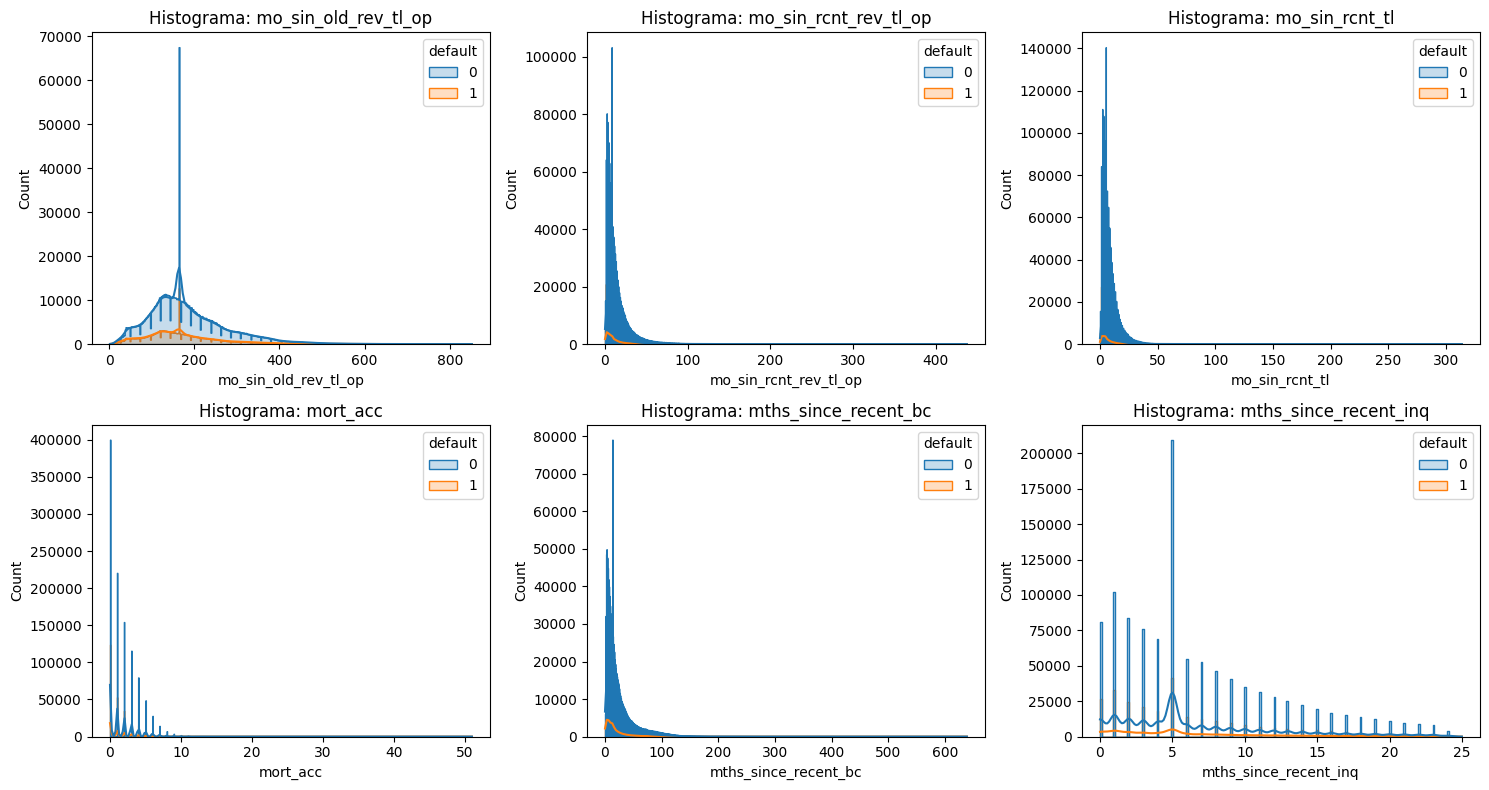

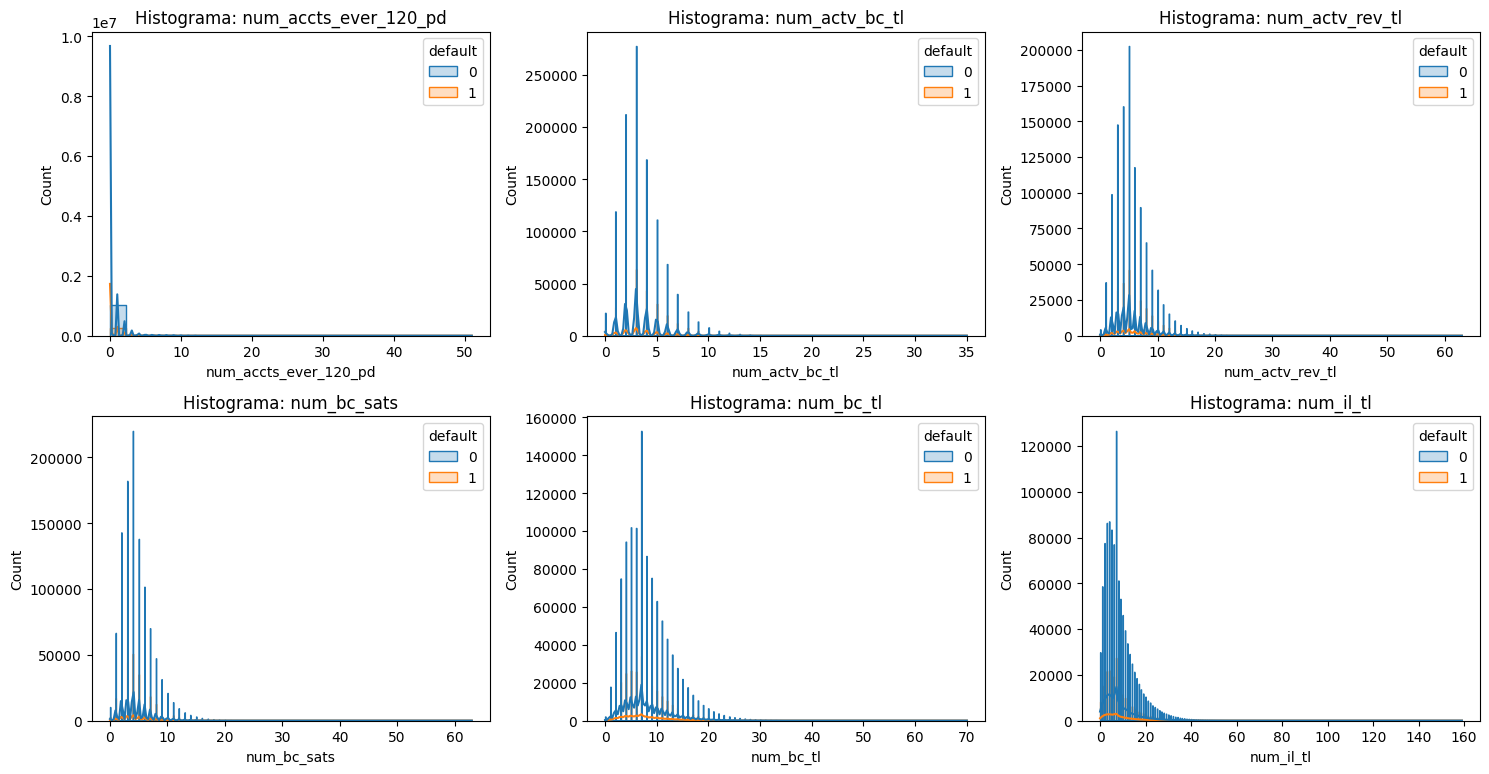

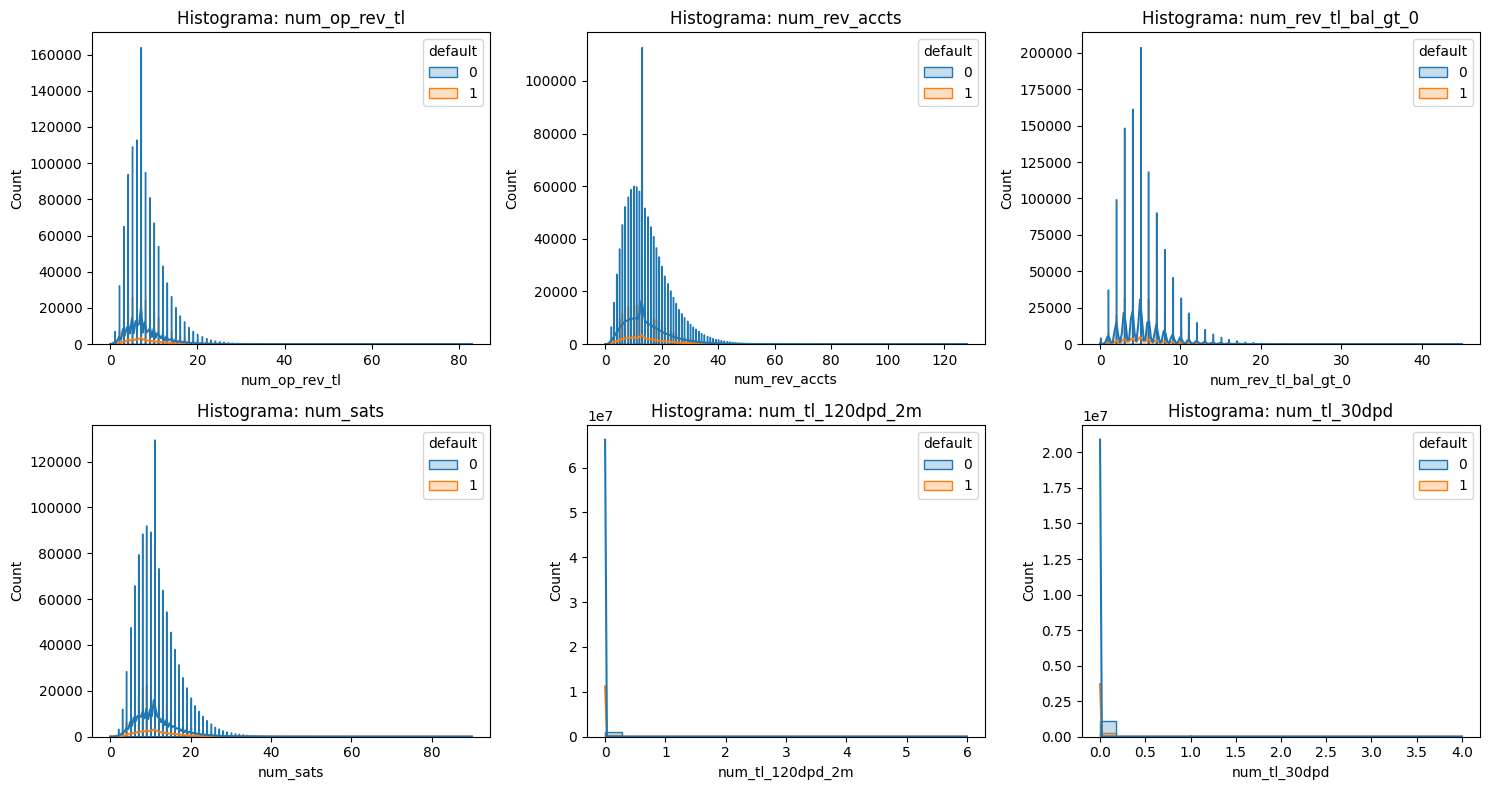

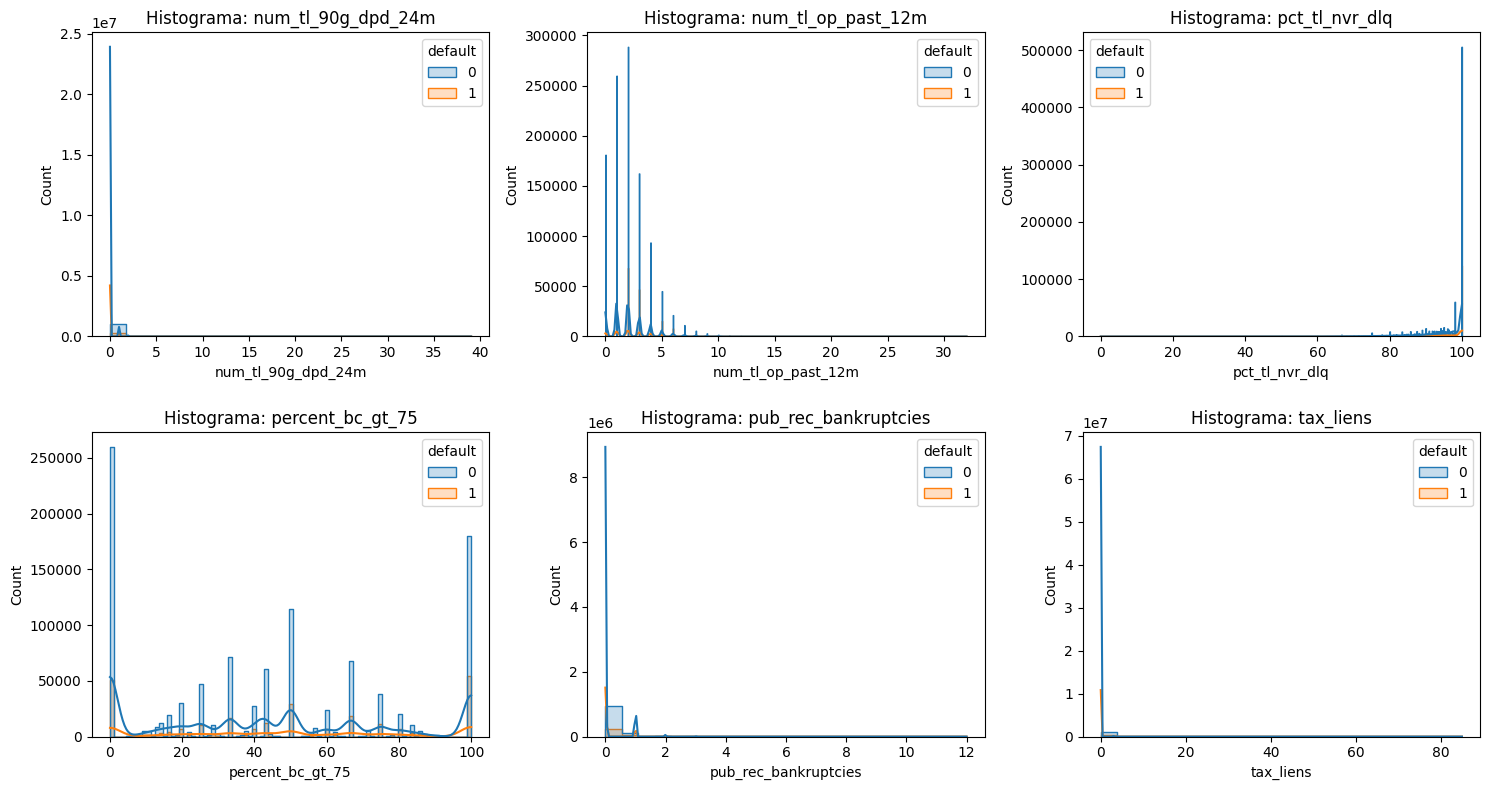

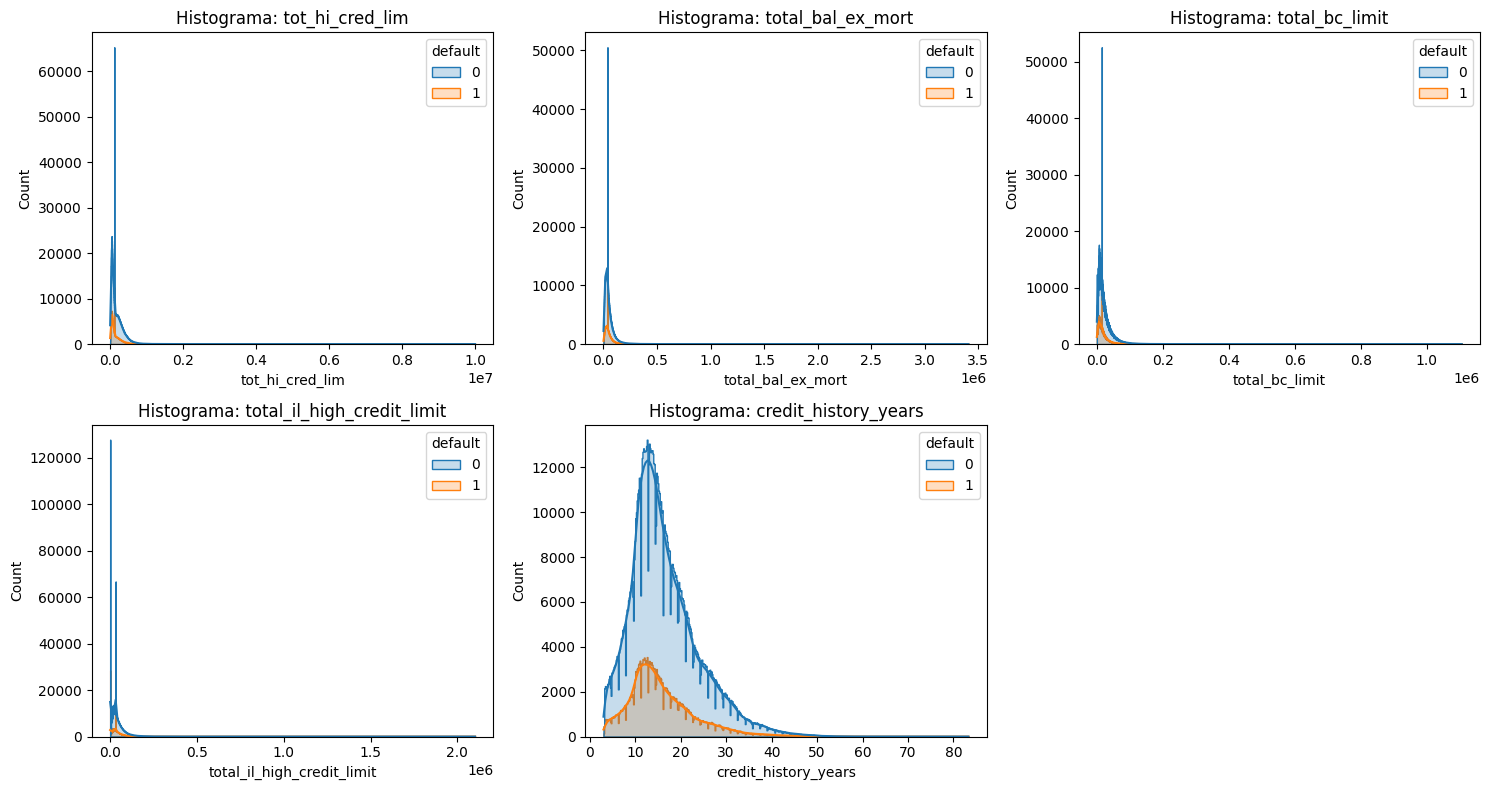

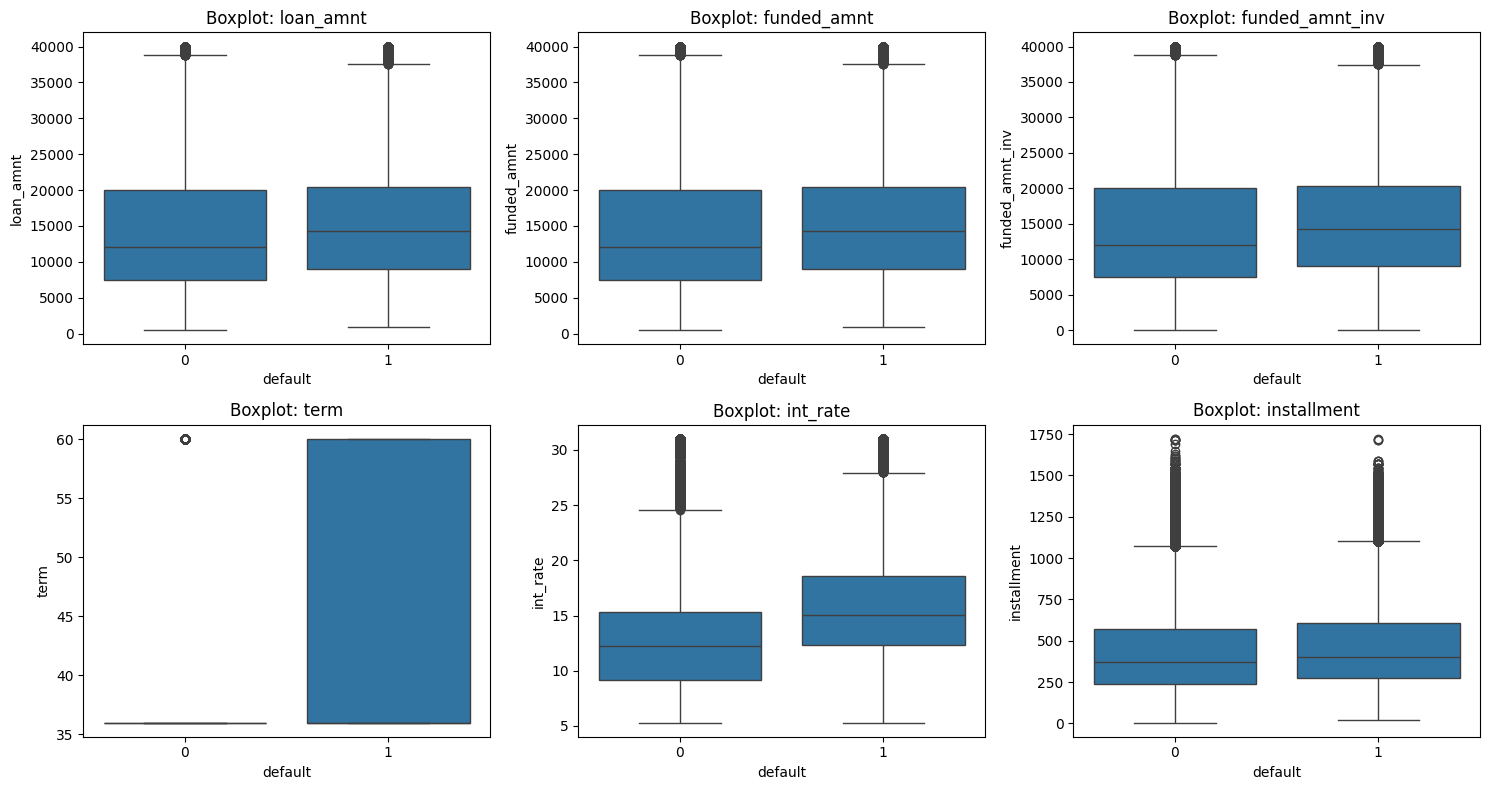

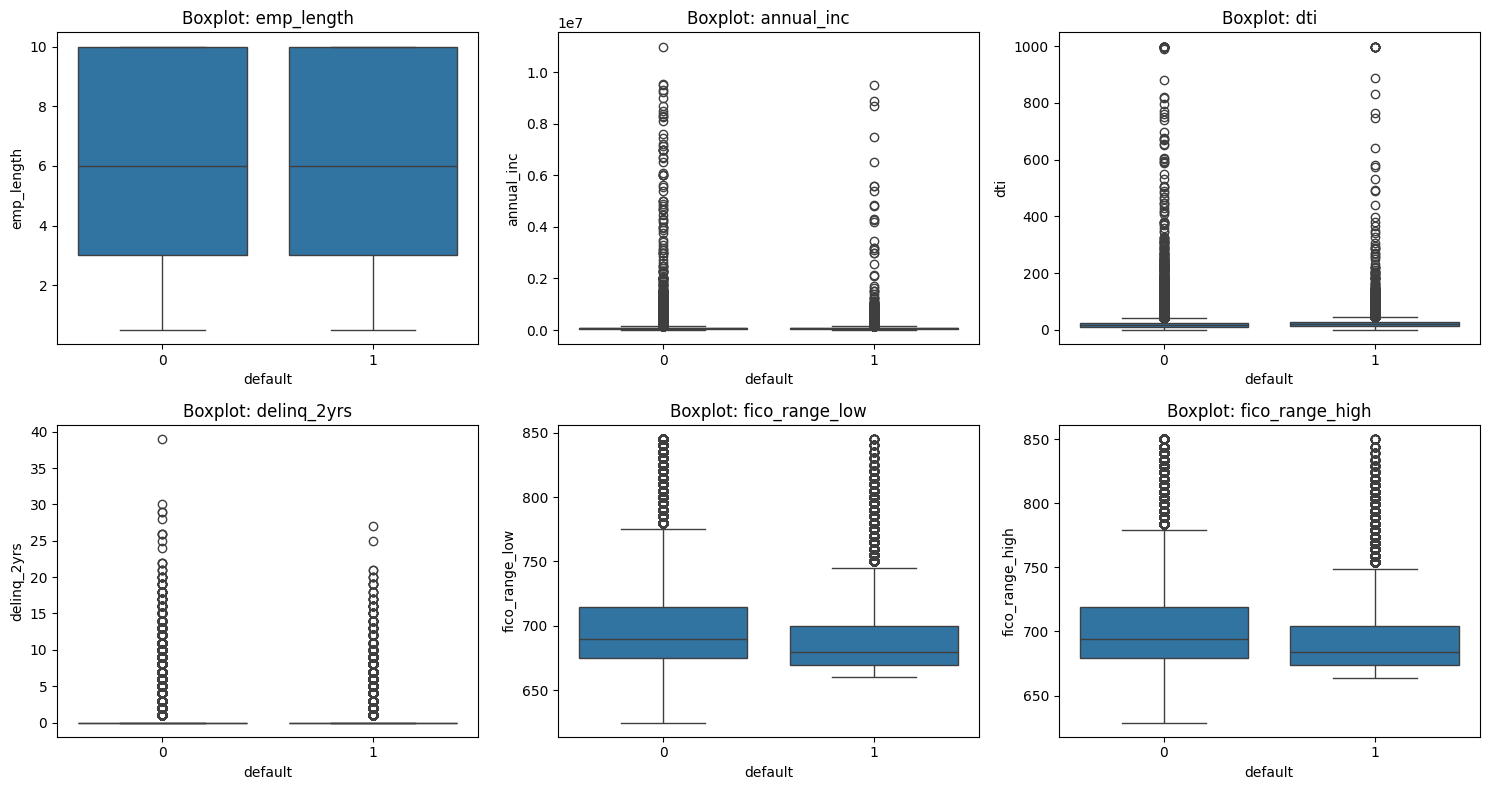

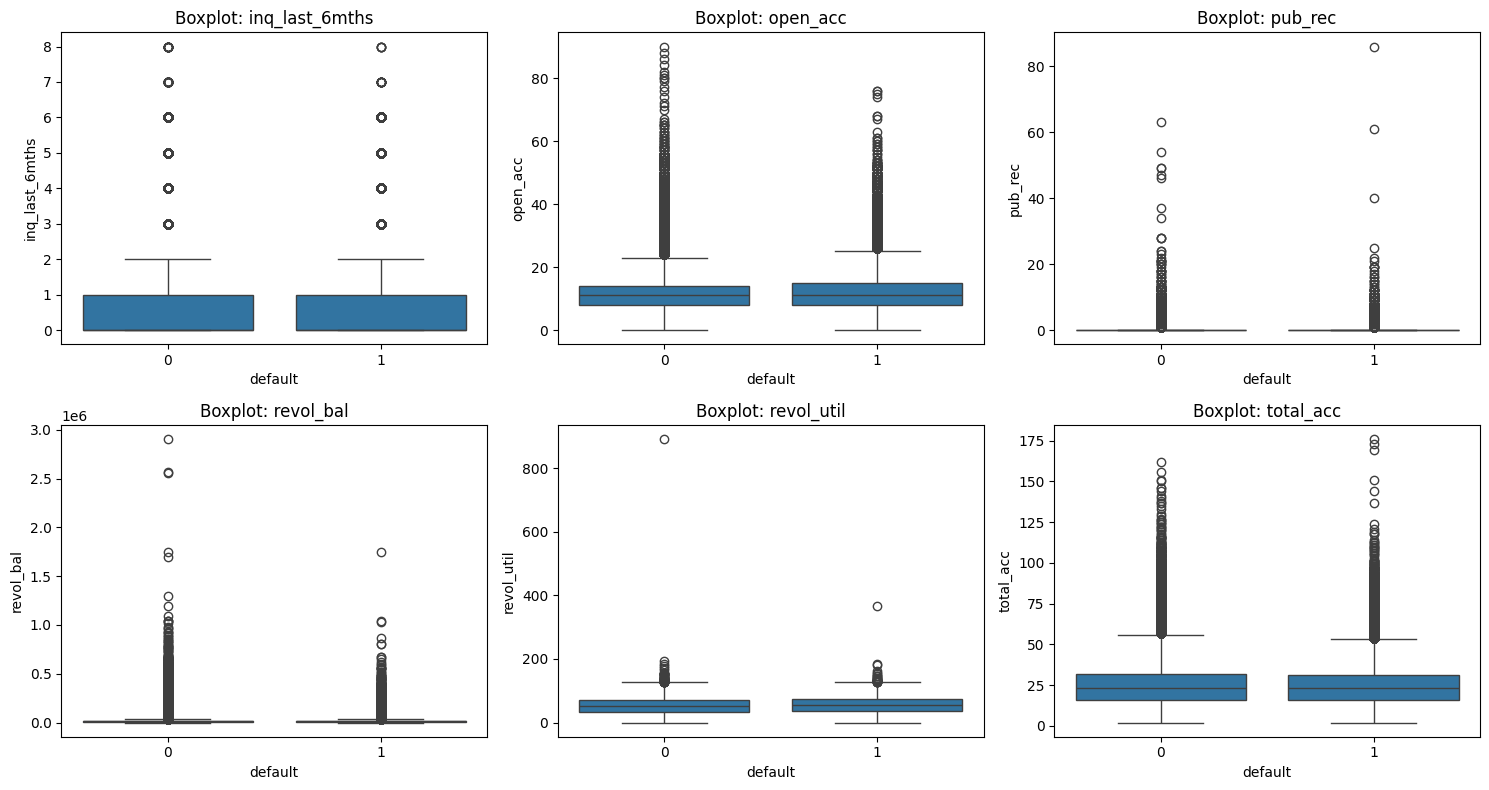

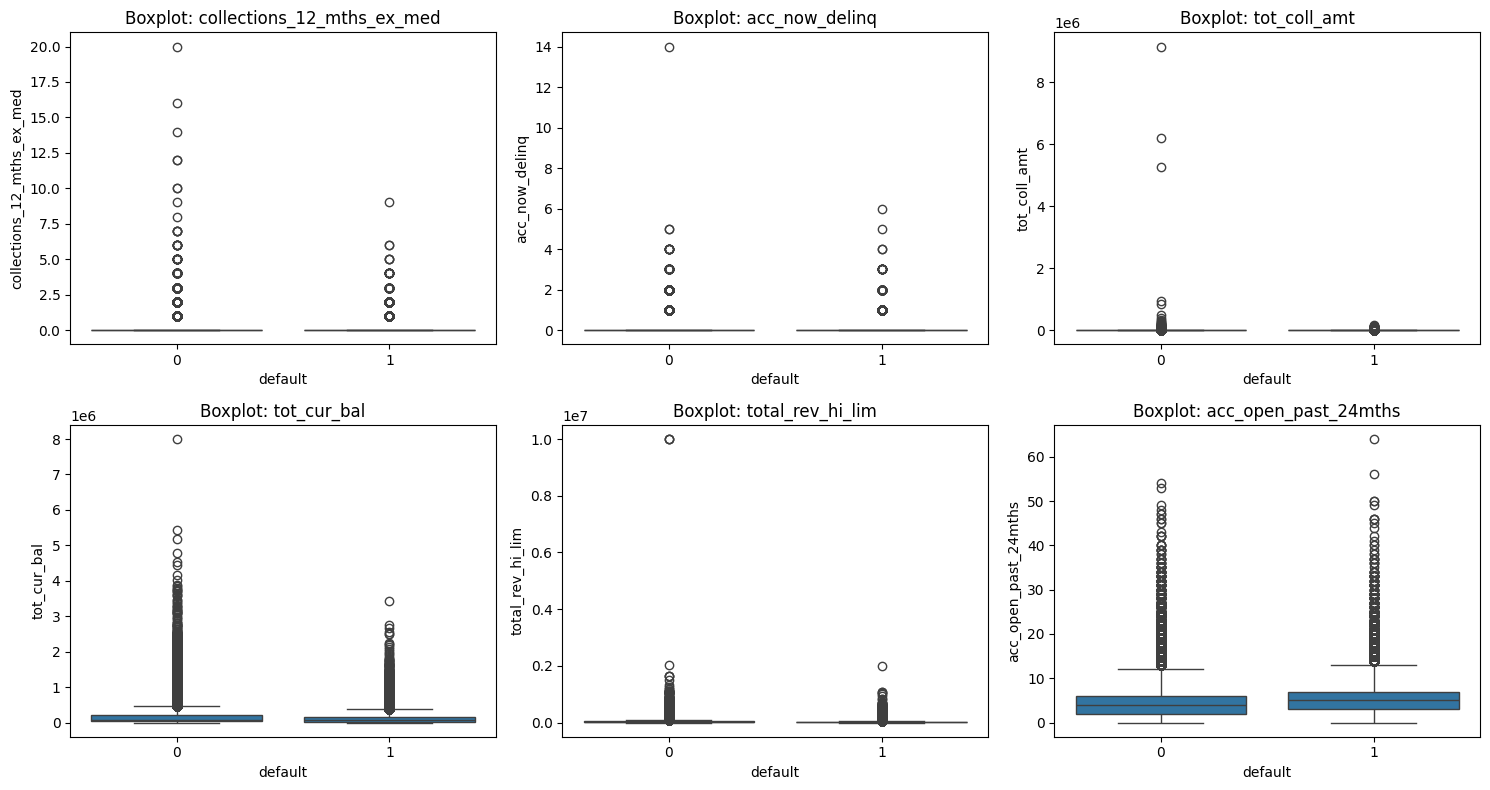

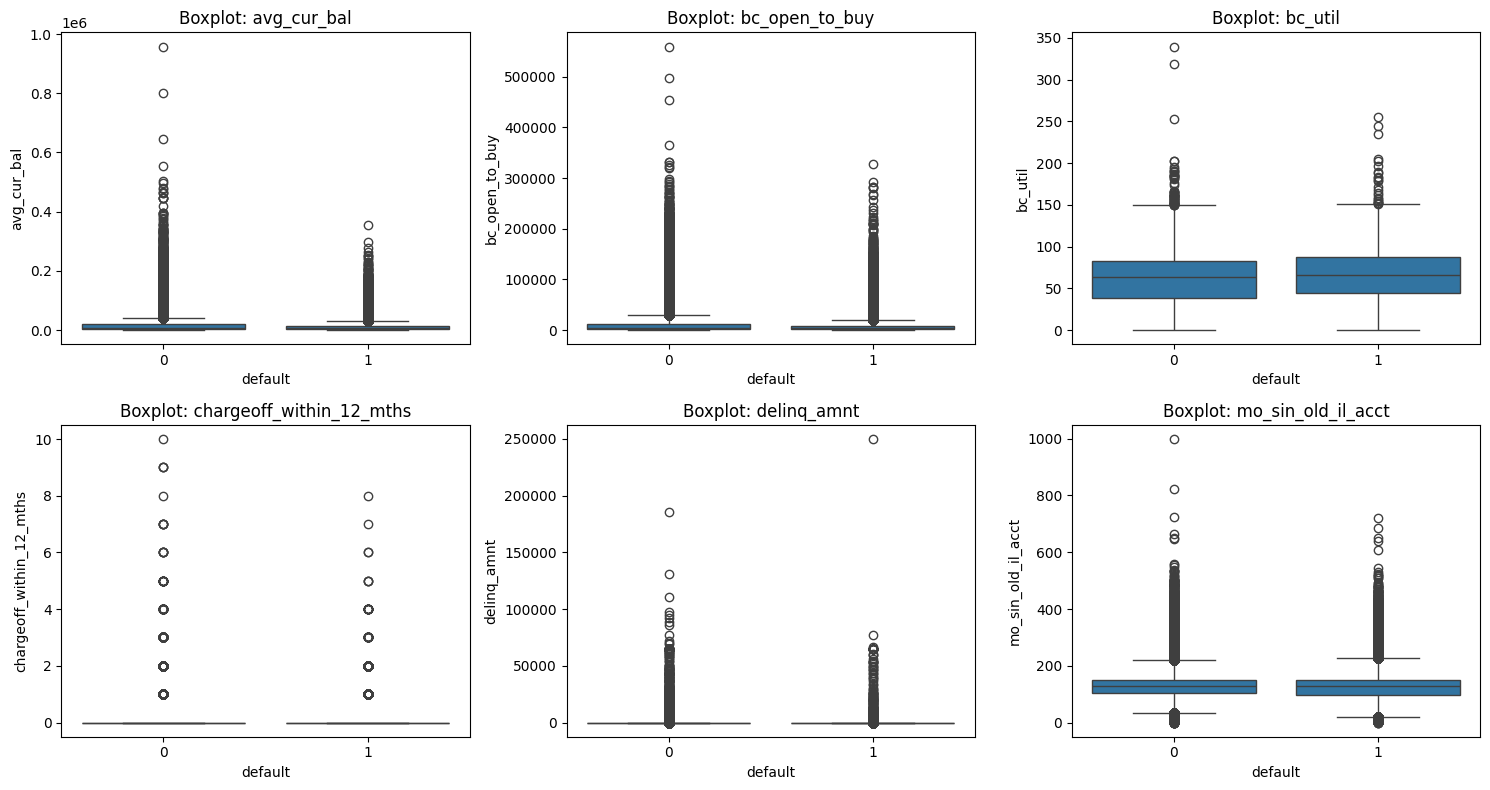

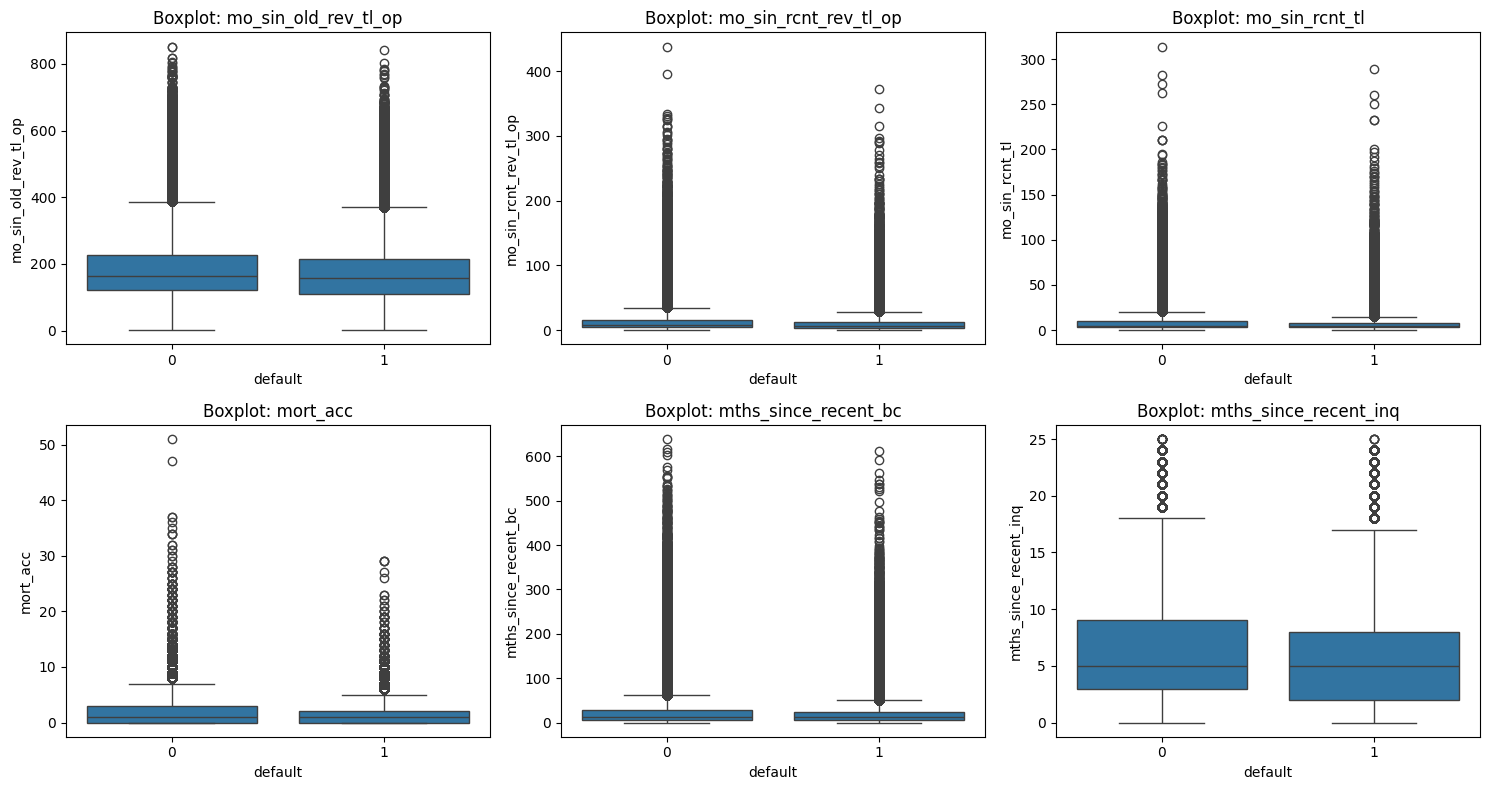

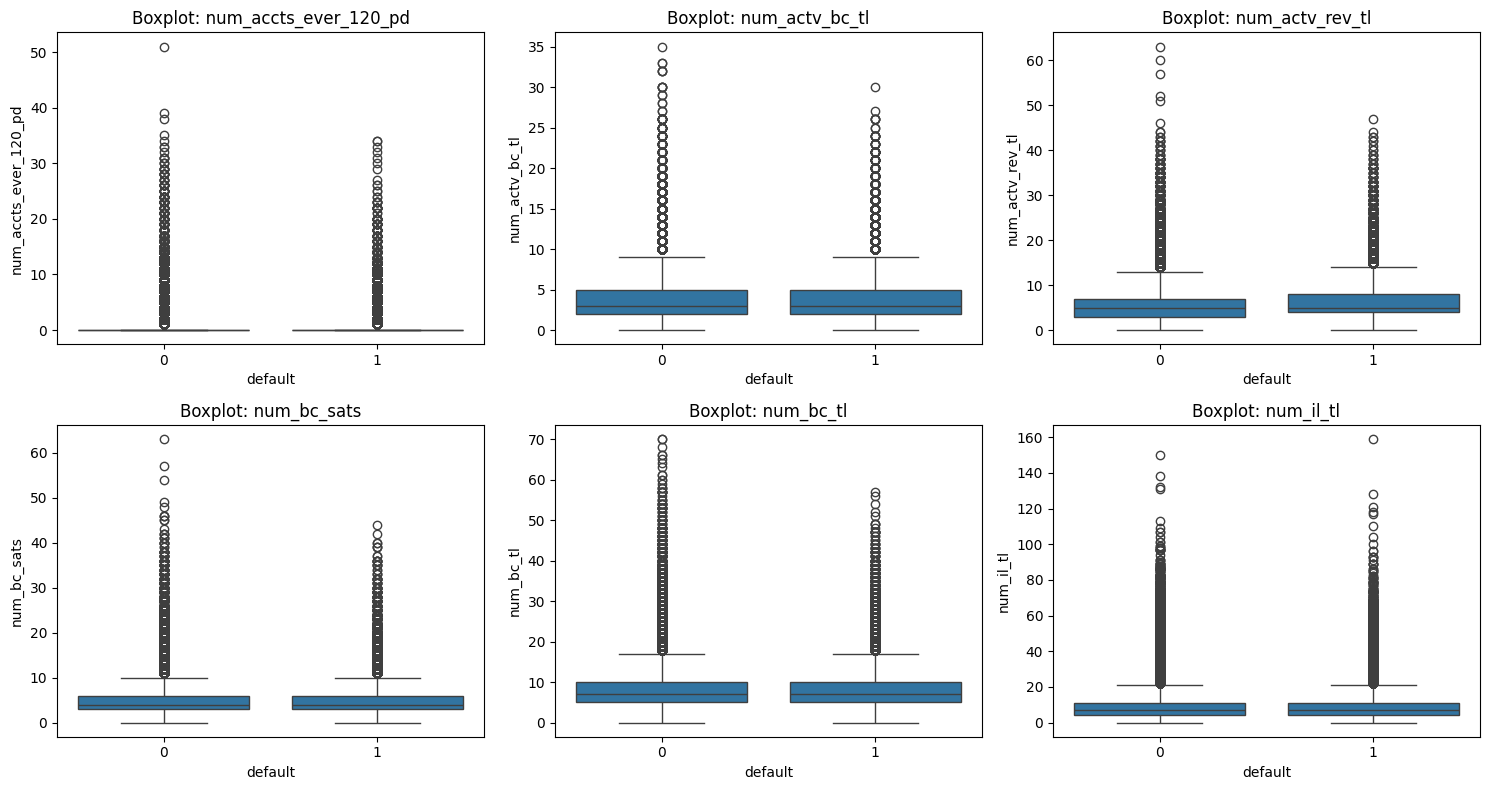

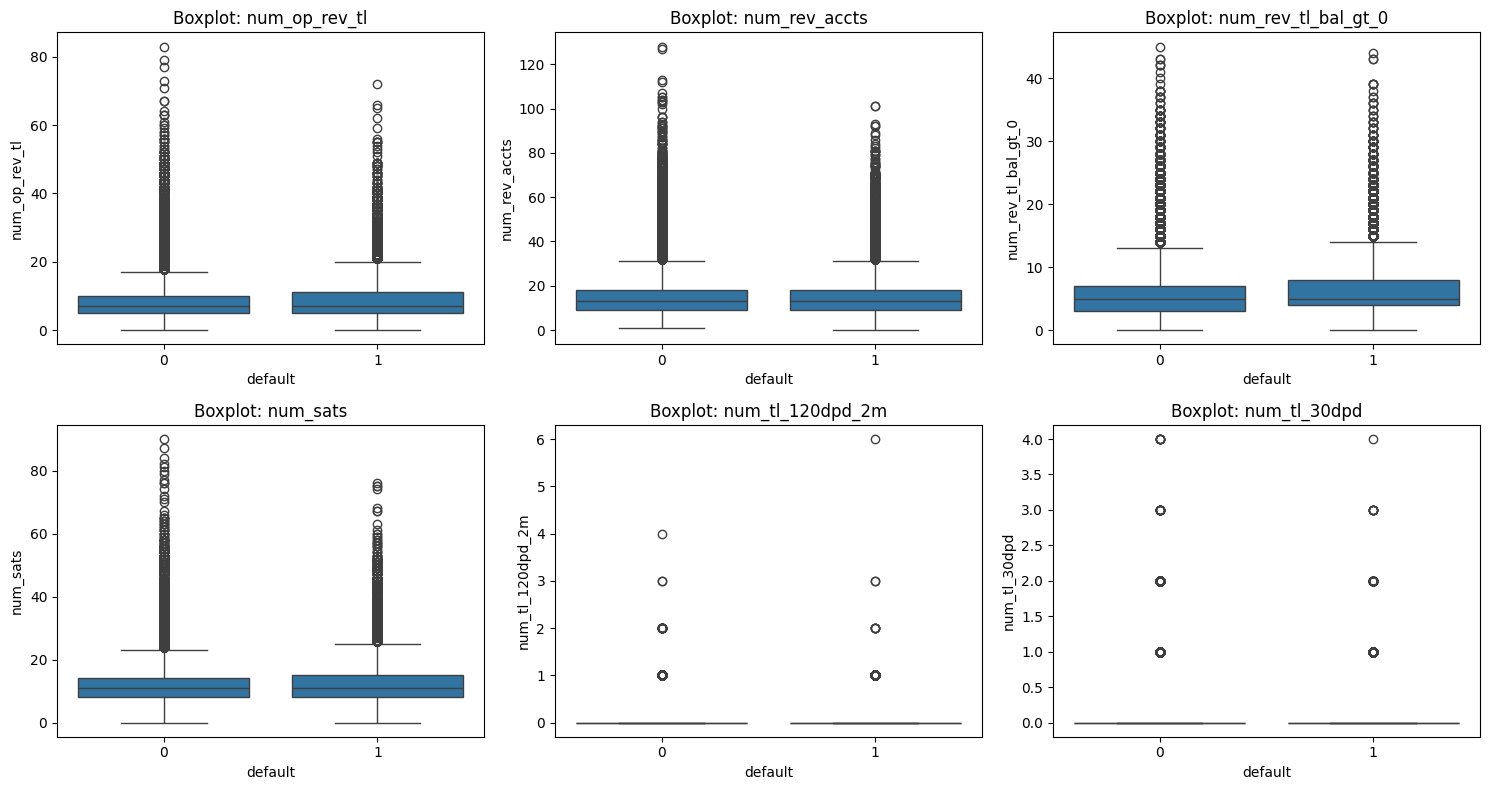

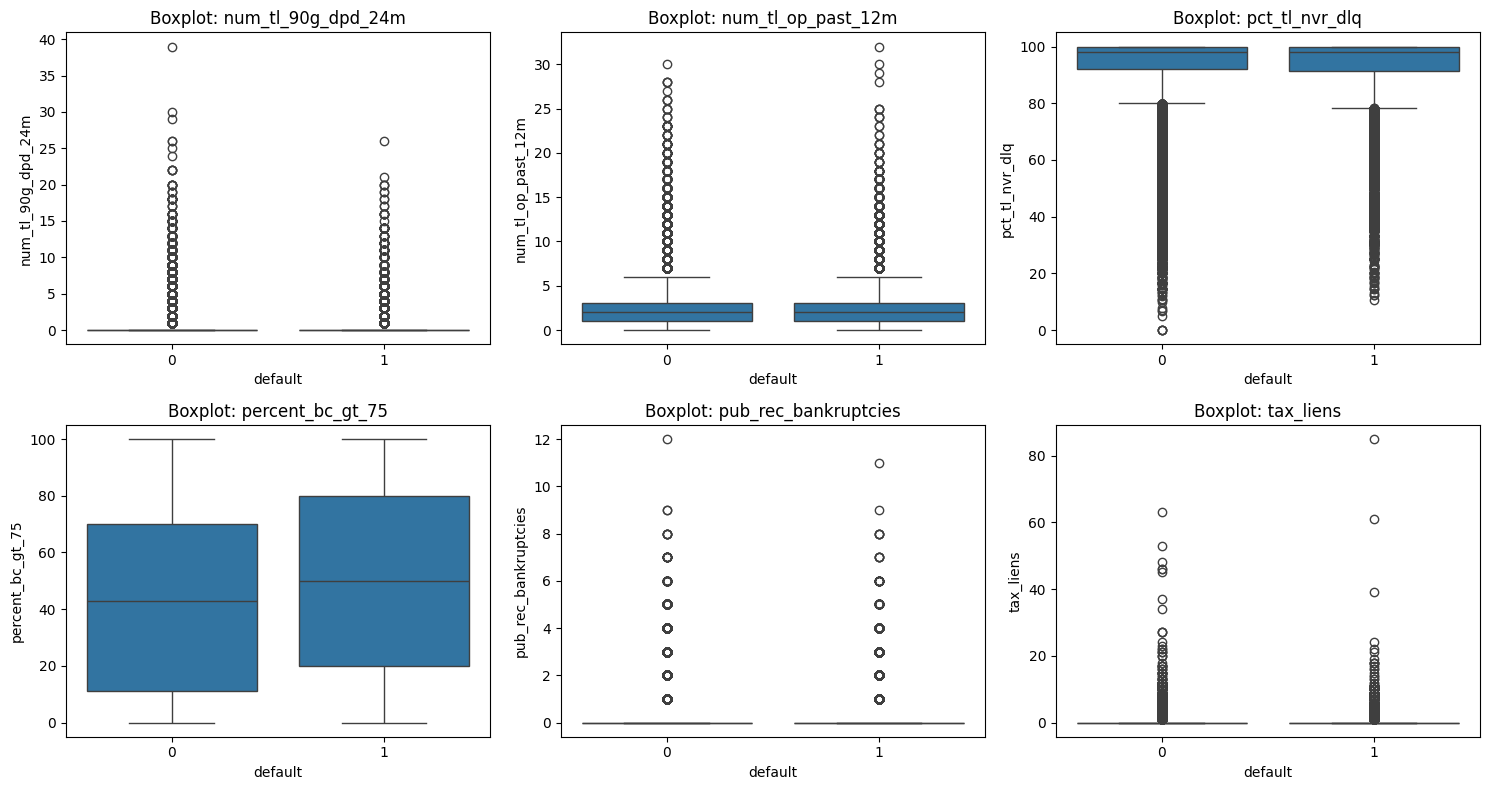

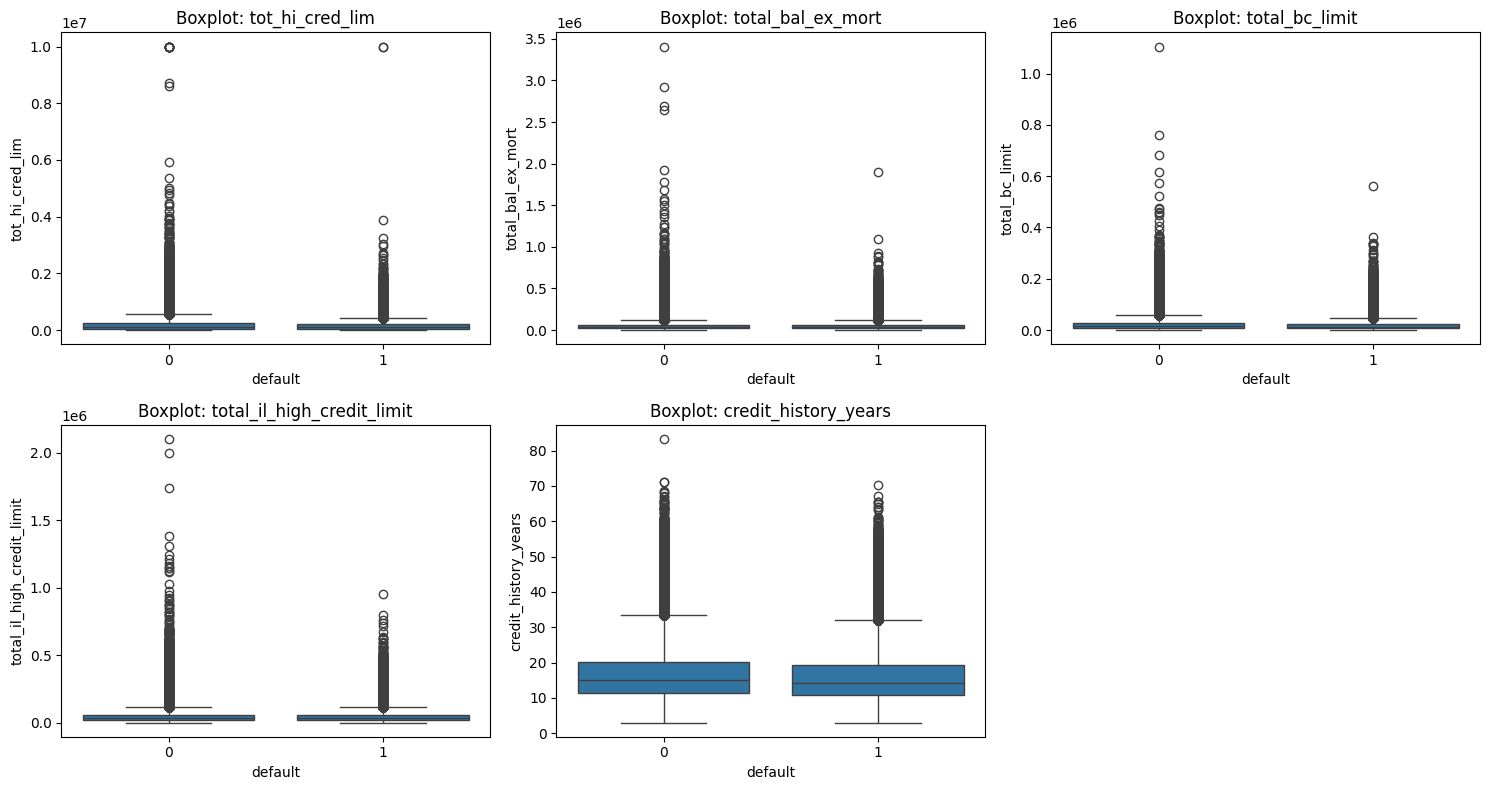

In [41]:
target = "default"   

num_vars = data.select_dtypes(include=np.number).columns.tolist()
if target in num_vars:
    num_vars.remove(target)

def plot_grid(data, variables, target, kind="hist", cols=3, rows=2):

    total = len(variables)
    per_page = cols * rows
    
    for i in range(0, total, per_page):
        subset = variables[i:i+per_page]
        
        fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
        axes = axes.flatten()
        
        for j, var in enumerate(subset):
            ax = axes[j]
            
            if kind == "hist":
                sns.histplot(data=data, x=var, hue=target, kde=True, element="step", ax=ax)
                ax.set_title(f"Histograma: {var}")
            
            elif kind == "box":
                sns.boxplot(data=data, x=target, y=var, ax=ax)
                ax.set_title(f"Boxplot: {var}")
        
        # Quitar ejes vacíos si sobran
        for k in range(len(subset), len(axes)):
            fig.delaxes(axes[k])
        
        plt.tight_layout()
        plt.show()

plot_grid(data, num_vars, target, kind="hist", cols=3, rows=2)

plot_grid(data, num_vars, target, kind="box", cols=3, rows=2)

Aspectos generales importantes que se pueden mencionar a partir de estos gráficos son:

- Las variables `loan_amnt`, `funded_amnt` y `funded_amnt_inv` aparentan presentar el mismo comportamiento y distribución. Esto es indicio de correlación entre ellas.

- En cuanto a las variables `installment`, `dti`, `revol_util`, `term` y `credit_history_years`, se observa una notable distribución entre clases. Notando, más específicamente en los histogramas, diferencias en las líneas de densidad donde la azul está muy por encima de la amarilla.

- Por otro lado, un par de columnas que también dan indicios de correlación fuerte son `fico_range_low` y `fico_range_high`.

- Lo mismo ocurre con el grupo de variables `mo_sin_rcnt_rev_tl_op`, `mo_sin_rcnt_tl`, `mths_since_recent_bc`.

- Cabe mencionar que existe un notoria cantidad de variables que, a la hora de mostrar sus boxplots por clase, evidenciaron datos atípicos. En teoría, estos deberían ser imputados, sin embargo, dado que representan a casos de la vida real, no se relaizará la respectiva imputación para no sesgar la naturaleza real.

### **Categóricas**

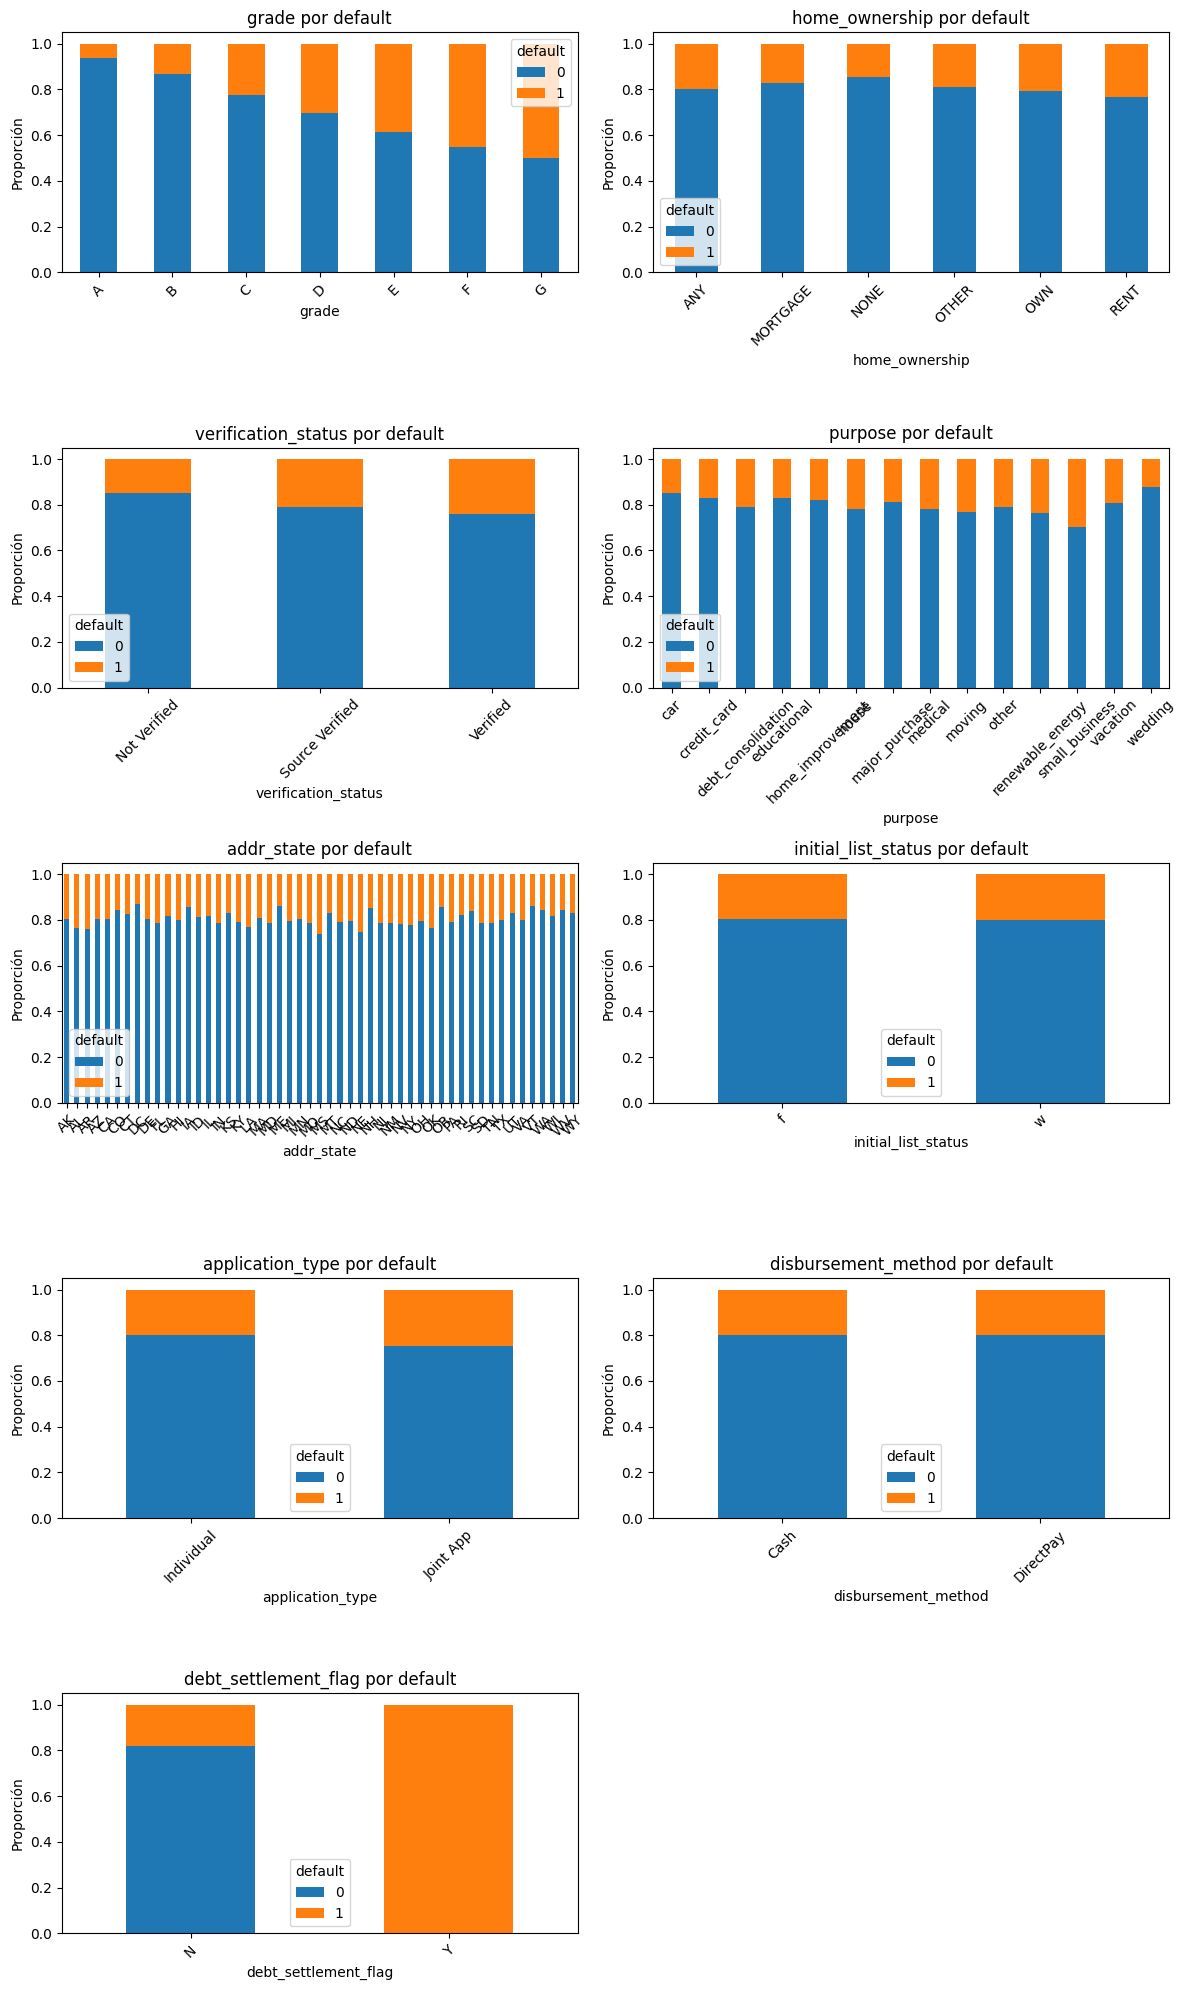

In [41]:
import matplotlib.pyplot as plt
import pandas as pd
import math

target = "default"

# Seleccionamos las variables categóricas
cat_vars = data.select_dtypes(exclude='number').columns.tolist()

# Definimos el tamaño de la cuadrícula
n_vars = len(cat_vars)
n_cols = 2  # puedes ajustar el número de columnas
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, n_rows*4))
axes = axes.flatten()  # aplanamos en caso de tener más de 1 fila

for i, col in enumerate(cat_vars):
    # Tabla de proporciones por clase
    prop = pd.crosstab(data[col], data[target], normalize='index')
    
    # Gráfico de barras apiladas
    prop.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f"{col} por {target}")
    axes[i].set_ylabel("Proporción")
    axes[i].set_xlabel(col)
    axes[i].legend(title=target)
    axes[i].tick_params(axis='x', rotation=45)

# Si hay subplots vacíos, los eliminamos
for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

- Al observar estos gráficos que representan la distribución de las clases de la variable objetivo en cada categoría perteneciente a su respectiva columna, podemos afirmar que en la mayoría de los casos, tal como era de esperarse, predominó la de `default = 0` que representa a los **Fully Paid**.

- Sobre la variable `grade`, se puede mencionar que a medida que disminuye el grado asignado, aumentan los registros correspondintes a `default = 1`, es decir, **Charged Off**. Esto da indicios de que a menor categoría, mayor es la probabilidad de que se prediga que quedará en mora.

- Respecto a `debt_settlement_flag`, cabe decir que ocurre algo alejado del comportamiento general. Para esta variable en específico, una de sus categorías está representada en su totalidad por `default = 1`. 

- Las variables restantes presentan distribuciones similares, en el sentido de que siempre predomina la clase relacionada con los créditos pagados en su totalidad.

### **Multicolinealidad**

En este apartado, vamos a verificar qué tan relacionadas están las variables entre sí.

In [42]:
numvarscorr = data.select_dtypes(include=['int64', 'float64'])
corr_matrix = numvarscorr.corr()

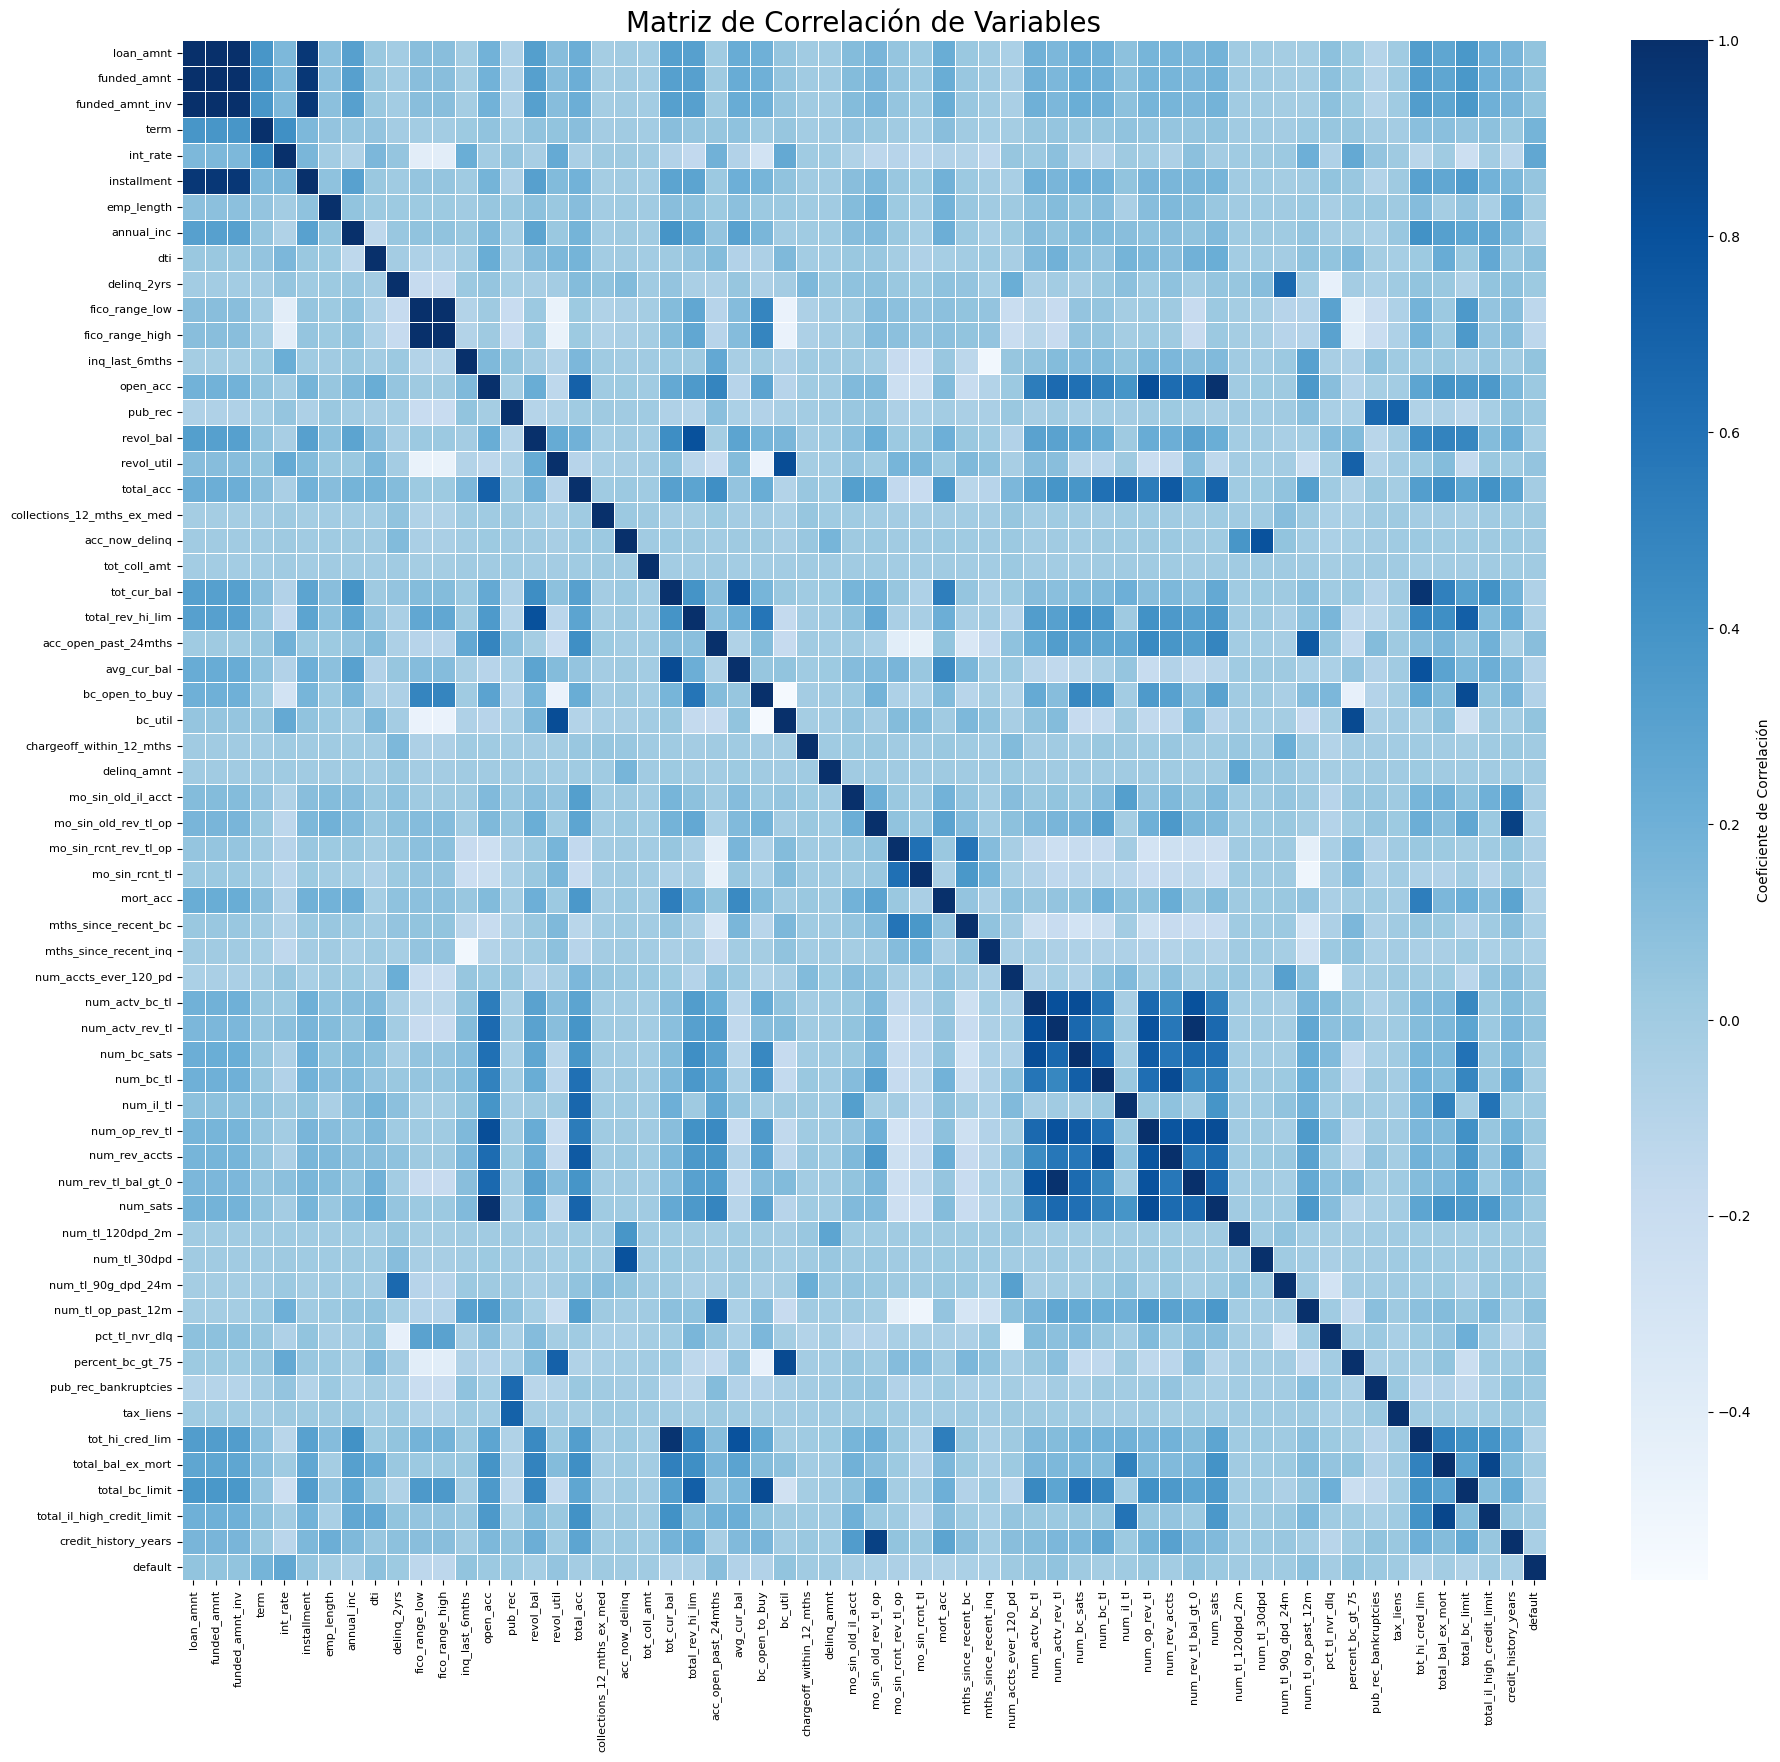

In [43]:
plt.figure(figsize=(22, 20))
sns.heatmap(
    corr_matrix,
    annot=False,   
    cmap='Blues',
    linewidths=.5,
    cbar_kws={'label': 'Coeficiente de Correlación'}
)
plt.title('Matriz de Correlación de Variables', fontsize=20)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.show()

Al observar la matriz, notamos que es evidente que existen altas correlaciones entre las variables, tanto positivas como negativas.

Veamos cuáles son para poder decidir con cuáles podemos quedarnos.

In [44]:
target = 'default'
umbral = 0.8

results = []

for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # evitar duplicados
            corr_value = corr_matrix.loc[col1, col2]
            if abs(corr_value) > umbral:
                # correlación con target
                corrobj1 = corr_matrix.loc[col1, target] if col1 != target else np.nan
                corrobj2 = corr_matrix.loc[col2, target] if col2 != target else np.nan
                
                # sugerencia: quedarse con la de mayor correlación con el target
                idea = col1 if abs(corrobj1) >= abs(corrobj2) else col2
                corr_target = corrobj1 if idea == col1 else corrobj2
                
                results.append({
                    "Par de Variables": f"{col1} & {col2}",
                    "Correlación entre variables": corr_value,
                })

duo_recomendado = pd.DataFrame(results)

tabla3 = (duo_recomendado.style
               .set_caption("Correlaciones Fuertes")
               .set_properties(**{
                   'background-color': 'white',
                   'color': 'black',
                   'font-size': '11pt'
               })
               .set_table_styles([
                   {'selector': 'th',
                    'props': [('background-color', '#00b4d8'),  
                              ('color', 'black'),
                              ('font-weight', 'bold')]}
               ])
              )

display(tabla3)


,Par de Variables,Correlación entre variables
0,funded_amnt & loan_amnt,0.999562
1,funded_amnt & funded_amnt_inv,0.999095
2,funded_amnt & installment,0.954053
3,funded_amnt_inv & loan_amnt,0.998567
4,funded_amnt_inv & installment,0.953064
5,installment & loan_amnt,0.953401
6,fico_range_high & fico_range_low,1.000000
7,revol_bal & total_rev_hi_lim,0.801189
8,tot_cur_bal & tot_hi_cred_lim,0.972951
9,avg_cur_bal & tot_cur_bal,0.836222


In [ ]:
groups = [
    ['funded_amnt', 'loan_amnt', 'funded_amnt_inv', 'installment'],  # Grupo 1
    ['fico_range_high', 'fico_range_low'],                             # Grupo 2
    ['revol_bal', 'total_rev_hi_lim', 'tot_cur_bal', 'tot_hi_cred_lim', 'avg_cur_bal'],  # Grupo 3
    ['bc_open_to_buy', 'total_bc_limit', 'bc_util', 'revol_util', 'percent_bc_gt_75'],   # Grupo 4
    ['num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_rev_tl_bal_gt_0',
     'num_bc_tl', 'num_rev_accts', 'num_op_rev_tl', 'num_sats', 'open_acc']             # Grupo 5
]

# Variables que decidimos conservar de cada grupo
keep_vars = [
    'funded_amnt',      # Grupo 1
    'fico_range_low',   # Grupo 2
    'tot_hi_cred_lim',  # Grupo 3
    'bc_util',          # Grupo 4
    'num_actv_rev_tl',  # Grupo 5
    'open_acc'          # Grupo 5 (ya estaba incluida en la anterior)
]

to_drop = []
for group in groups:
    for var in group:
        if var not in keep_vars:
            to_drop.append(var)

data.drop(columns=to_drop, inplace=True)

data.head()


,funded_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,inq_last_6mths,open_acc,pub_rec,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,acc_open_past_24mths,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_rev_tl,num_il_tl,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,credit_history_years,default
0,3600.0,36,13.99,C,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,675.0,1.0,7.0,0.0,13.0,w,0.0,Individual,0.0,722.0,4.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,4.0,3.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,178050.0,7746.0,13734.0,Cash,N,12.342466,0
1,24700.0,36,11.99,C,10.0,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,715.0,4.0,22.0,0.0,38.0,w,0.0,Individual,0.0,0.0,4.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,6.0,0.0,0.0,0.0,2.0,97.4,0.0,0.0,314017.0,39475.0,24667.0,Cash,N,16.010959,0
2,20000.0,60,10.78,B,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,695.0,0.0,6.0,0.0,18.0,w,0.0,Joint App,0.0,0.0,6.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,10.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,218418.0,18696.0,14877.0,Cash,N,15.342466,0
4,10400.0,60,22.45,F,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,695.0,3.0,12.0,0.0,35.0,w,0.0,Individual,0.0,0.0,10.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,6.0,10.0,0.0,0.0,0.0,4.0,96.6,0.0,0.0,439570.0,95768.0,88097.0,Cash,N,17.512329,0
5,11950.0,36,13.44,C,4.0,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,690.0,0.0,5.0,0.0,6.0,w,0.0,Individual,0.0,0.0,0.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,5.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,16900.0,12798.0,4000.0,Cash,N,28.186301,0


A partir de la matriz de correlación, se identificó claramente la existencia de correlaciones muy fuertes entre variables. Al analizar, se borraron las variables que se consideraron menos informativas o útiles en comparación con las que continúan en nuestro dataset.

Finalmente, se aplicará un **VIF**, esto con el fin de dejar la base de datos efectivamente preprocesada y limpiada para los modelos a implementar.

In [48]:
X = data.drop(columns=['default'])

X_numeric = X.select_dtypes(include=np.number)

vif_threshold = 5

while True:
    vif_data = pd.DataFrame()
    vif_data["feature"] = X_numeric.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X_numeric.values, i)
        for i in range(len(X_numeric.columns))
    ]

    max_vif = vif_data['VIF'].max()

    if max_vif > vif_threshold:
        drop_feature = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']

        print(f"Eliminando '{drop_feature}' con un VIF de {max_vif:.2f}")

    
        X_numeric = X_numeric.drop(columns=[drop_feature])


        df_imp = data.drop(columns=[drop_feature])

    else:
        print("\nTodos los valores VIF están por debajo del umbral.")
        break

Eliminando 'fico_range_low' con un VIF de 248.51
Eliminando 'pct_tl_nvr_dlq' con un VIF de 35.57
Eliminando 'credit_history_years' con un VIF de 34.47
Eliminando 'total_acc' con un VIF de 25.65
Eliminando 'term' con un VIF de 20.19
Eliminando 'open_acc' con un VIF de 15.40
Eliminando 'total_bal_ex_mort' con un VIF de 10.84
Eliminando 'int_rate' con un VIF de 10.08
Eliminando 'pub_rec' con un VIF de 9.41
Eliminando 'acc_open_past_24mths' con un VIF de 8.51
Eliminando 'mo_sin_old_il_acct' con un VIF de 8.09
Eliminando 'mo_sin_old_rev_tl_op' con un VIF de 5.43
Eliminando 'bc_util' con un VIF de 5.41

Todos los valores VIF están por debajo del umbral.


In [53]:
data

,funded_amnt,term,int_rate,grade,emp_length,home_ownership,annual_inc,verification_status,purpose,addr_state,dti,delinq_2yrs,fico_range_low,inq_last_6mths,open_acc,pub_rec,total_acc,initial_list_status,collections_12_mths_ex_med,application_type,acc_now_delinq,tot_coll_amt,acc_open_past_24mths,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_inq,num_accts_ever_120_pd,num_actv_rev_tl,num_il_tl,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_il_high_credit_limit,disbursement_method,debt_settlement_flag,credit_history_years,default
0,3600.0,36,13.99,C,10.0,MORTGAGE,55000.0,Not Verified,debt_consolidation,PA,5.91,0.0,675.0,1.0,7.0,0.0,13.0,w,0.0,Individual,0.0,722.0,4.0,37.2,0.0,0.0,148.0,128.0,3.0,3.0,1.0,4.0,4.0,2.0,4.0,3.0,0.0,0.0,0.0,3.0,76.9,0.0,0.0,178050.0,7746.0,13734.0,Cash,N,12.342466,0
1,24700.0,36,11.99,C,10.0,MORTGAGE,65000.0,Not Verified,small_business,SD,16.06,1.0,715.0,4.0,22.0,0.0,38.0,w,0.0,Individual,0.0,0.0,4.0,27.1,0.0,0.0,113.0,192.0,2.0,2.0,4.0,2.0,0.0,0.0,5.0,6.0,0.0,0.0,0.0,2.0,97.4,0.0,0.0,314017.0,39475.0,24667.0,Cash,N,16.010959,0
2,20000.0,60,10.78,B,10.0,MORTGAGE,63000.0,Not Verified,home_improvement,IL,10.78,0.0,695.0,0.0,6.0,0.0,18.0,w,0.0,Joint App,0.0,0.0,6.0,55.9,0.0,0.0,125.0,184.0,14.0,14.0,5.0,101.0,10.0,0.0,3.0,6.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,218418.0,18696.0,14877.0,Cash,N,15.342466,0
4,10400.0,60,22.45,F,3.0,MORTGAGE,104433.0,Source Verified,major_purchase,PA,25.37,1.0,695.0,3.0,12.0,0.0,35.0,w,0.0,Individual,0.0,0.0,10.0,77.5,0.0,0.0,128.0,210.0,4.0,4.0,6.0,4.0,1.0,0.0,6.0,10.0,0.0,0.0,0.0,4.0,96.6,0.0,0.0,439570.0,95768.0,88097.0,Cash,N,17.512329,0
5,11950.0,36,13.44,C,4.0,RENT,34000.0,Source Verified,debt_consolidation,GA,10.20,0.0,690.0,0.0,5.0,0.0,6.0,w,0.0,Individual,0.0,0.0,0.0,91.0,0.0,0.0,338.0,54.0,32.0,32.0,0.0,36.0,5.0,0.0,3.0,2.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,16900.0,12798.0,4000.0,Cash,N,28.186301,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2260688,18000.0,60,9.49,B,5.0,OWN,130000.0,Not Verified,home_improvement,TX,20.59,0.0,735.0,1.0,17.0,0.0,39.0,f,0.0,Individual,0.0,0.0,6.0,68.2,0.0,0.0,113.0,146.0,17.0,15.0,3.0,17.0,2.0,0.0,9.0,21.0,0.0,0.0,0.0,0.0,100.0,0.0,0.0,275356.0,54349.0,77756.0,Cash,N,12.260274,0
2260690,29400.0,60,13.99,C,9.0,MORTGAGE,180792.0,Not Verified,debt_consolidation,CA,22.03,0.0,705.0,1.0,16.0,0.0,32.0,f,0.0,Individual,0.0,0.0,4.0,69.4,0.0,0.0,145.0,174.0,31.0,8.0,3.0,70.0,3.0,0.0,5.0,17.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,719056.0,148305.0,95702.0,Cash,N,14.597260,0
2260691,32000.0,60,14.49,C,3.0,MORTGAGE,157000.0,Source Verified,home_improvement,AZ,10.34,0.0,735.0,0.0,14.0,0.0,18.0,f,0.0,Individual,0.0,0.0,10.0,10.6,0.0,0.0,53.0,63.0,4.0,4.0,3.0,4.0,15.0,0.0,8.0,4.0,0.0,0.0,0.0,2.0,100.0,0.0,0.0,524379.0,122872.0,23879.0,Cash,N,5.339726,1
2260692,16000.0,60,12.79,C,10.0,RENT,150000.0,Not Verified,medical,NC,12.25,0.0,665.0,0.0,12.0,4.0,28.0,f,0.0,Individual,0.0,0.0,9.0,73.1,0.0,0.0,147.0,229.0,17.0,4.0,0.0,17.0,12.0,1.0,4.0,15.0,0.0,0.0,0.0,2.0,92.0,3.0,0.0,87473.0,65797.0,73473.0,Cash,N,19.180822,0


In [54]:
cols_a_eliminar = [
    'fico_range_low', 'pct_tl_nvr_dlq', 'credit_history_years',
    'total_acc', 'open_acc', 'total_bal_ex_mort',
    'int_rate', 'pub_rec', 'acc_open_past_24mths',
    'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'bc_util'
]

datalimpio = data.drop(columns=cols_a_eliminar)

datalimpio.to_csv('datalimpia.csv', index=False)

## **Referencia bibliográfica**

Amirtharajanpks. (2019). Lending Club EDA [Notebook]. Kaggle. Recuperado de https://www.kaggle.com/code/amirtharajanpks/lending-club-eda